EOT20 (Empirical Ocean Tide 2020) model 

The EOT20 (Empirical Ocean Tide 2020) model is a global ocean tide model developed by DGFI-TUM (German Geodetic Research Institute) that specializes in providing precise tidal data, particularly for coastal regions. It is a semi-empirical model derived from over 27 years of multi-mission satellite altimetry data (1992–2019) to improve upon tide estimations in shallow water and coastal areas. 

Key Features of EOT20
Data Source & Coverage: Based on satellite missions including TOPEX/Poseidon, Jason-1, Jason-2, Jason-3, ERS-1, ERS-2, and Envisat. It provides global coverage (ranging from 66°S to 66°N).
Spatial Resolution: The ocean and load tide atlases are provided on a 

 grid (approximately 13-14 km).
Coastal Accuracy: Specifically designed to improve estimations within 3–7 km of the coast using ALES (Adaptive Leading Edge Subwaveform) retracker data, offering better results than its predecessor (EOT11a) in these regions.
Tidal Constituents: Includes 17 tidal constituents (e.g., 2N2, J1, K1, K2, M2, M4, MF, MM, N2, O1, P1, Q1, S1, S2, SA, SSA, T2). 
ResearchGate
ResearchGate
 +4
Accessing EOT20 Data
Download Source: The EOT20 data is open-access and available via SEANOE (Sea Scientific Open Data Publication) at this DOI: https://doi.org/10.17882/79489.
Formats: The data is provided in netCDF4 format, which includes tidal amplitudes and phases.
Integration Tool: eo-tides (geoscienceaustralia.github.io/eo-tides) is a tool that allows for easy setup, management, and application of the EOT20 model to satellite Earth observation datasets. 
ResearchGate
ResearchGate
 +4
EOT20 vs. Other Models
EOT20 is considered a state-of-the-art model on par with FES2014 (Finite Element Solution), with comparable performance in the open ocean and enhanced accuracy in specific coastal/shelf regions. The model serves as a key tool for tidal correction in satellite altimetry, particularly in coastal zones.

In [23]:
#INstalling necessary packages
#pip install pyTMD matplotlib numpy pandas timescale netCDF4 xarray planetary-computer


Before running the code I begin by downloading the EOT20 data files: EOT20 is a global model consisting of NetCDF files for 17 tidal constituents. Data is downloaded from DGFI-TUM:.

Defining location, calculates the tide heights over a 24-hour period using EOT20, and plotting the graph with markers for high and low tides.

Coordinate Reference: Mombasa is located at approximately $4.04^\circ S, 39.67^\circ E$.Constituent Summation: The EOT20 model provides amplitudes and phases for major tidal constituents (like $M_2, S_2, N_2, K_1, O_1$). The predict function performs the harmonic summation:$$h(t) = \sum_{i=1}^{n} f_i(t) A_i \cos(\omega_i t + V_i(t) + u_i(t) - \kappa_i)$$Lowest Tide Selection: The script scans 8,760 hours of 2026 to find the global minimum. For the Kenyan coast, this often aligns with the equinoxes (March or September) when the solar and lunar forces are most significant.

In [24]:
#confirming full EOT20 ocean tide constituent files.
import os

root = r"D:\other\4me\ocean_tides\EOT20\ocean_tides"

for path, dirs, files in os.walk(root):
    print("\n", path)
    for f in files[:20]:
        print("   ", f)


 D:\other\4me\ocean_tides\EOT20\ocean_tides
    2N2_ocean_eot20.nc
    J1_ocean_eot20.nc
    K1_ocean_eot20.nc
    K2_ocean_eot20.nc
    M2_ocean_eot20.nc
    M4_ocean_eot20.nc
    MF_ocean_eot20.nc
    MM_ocean_eot20.nc
    N2_ocean_eot20.nc
    O1_ocean_eot20.nc
    P1_ocean_eot20.nc
    Q1_ocean_eot20.nc
    S1_ocean_eot20.nc
    S2_ocean_eot20.nc
    SA_ocean_eot20.nc
    SSA_ocean_eot20.nc
    T2_ocean_eot20.nc


The next step is to inspect one file to determine:
variable names for amplitude and phase coordinate names (lat/lon or latitude/longitude)

;APA Style
Xia, Q., Qin, C.-Z., Li, H., Huang, C., & Su, F.-Z. (2018). Mapping Mangrove Forests Based on Multi-Tidal High-Resolution Satellite Imagery. Remote Sensing, 10(9), 1343. https://doi.org/10.3390/rs10091343

tiadal gate 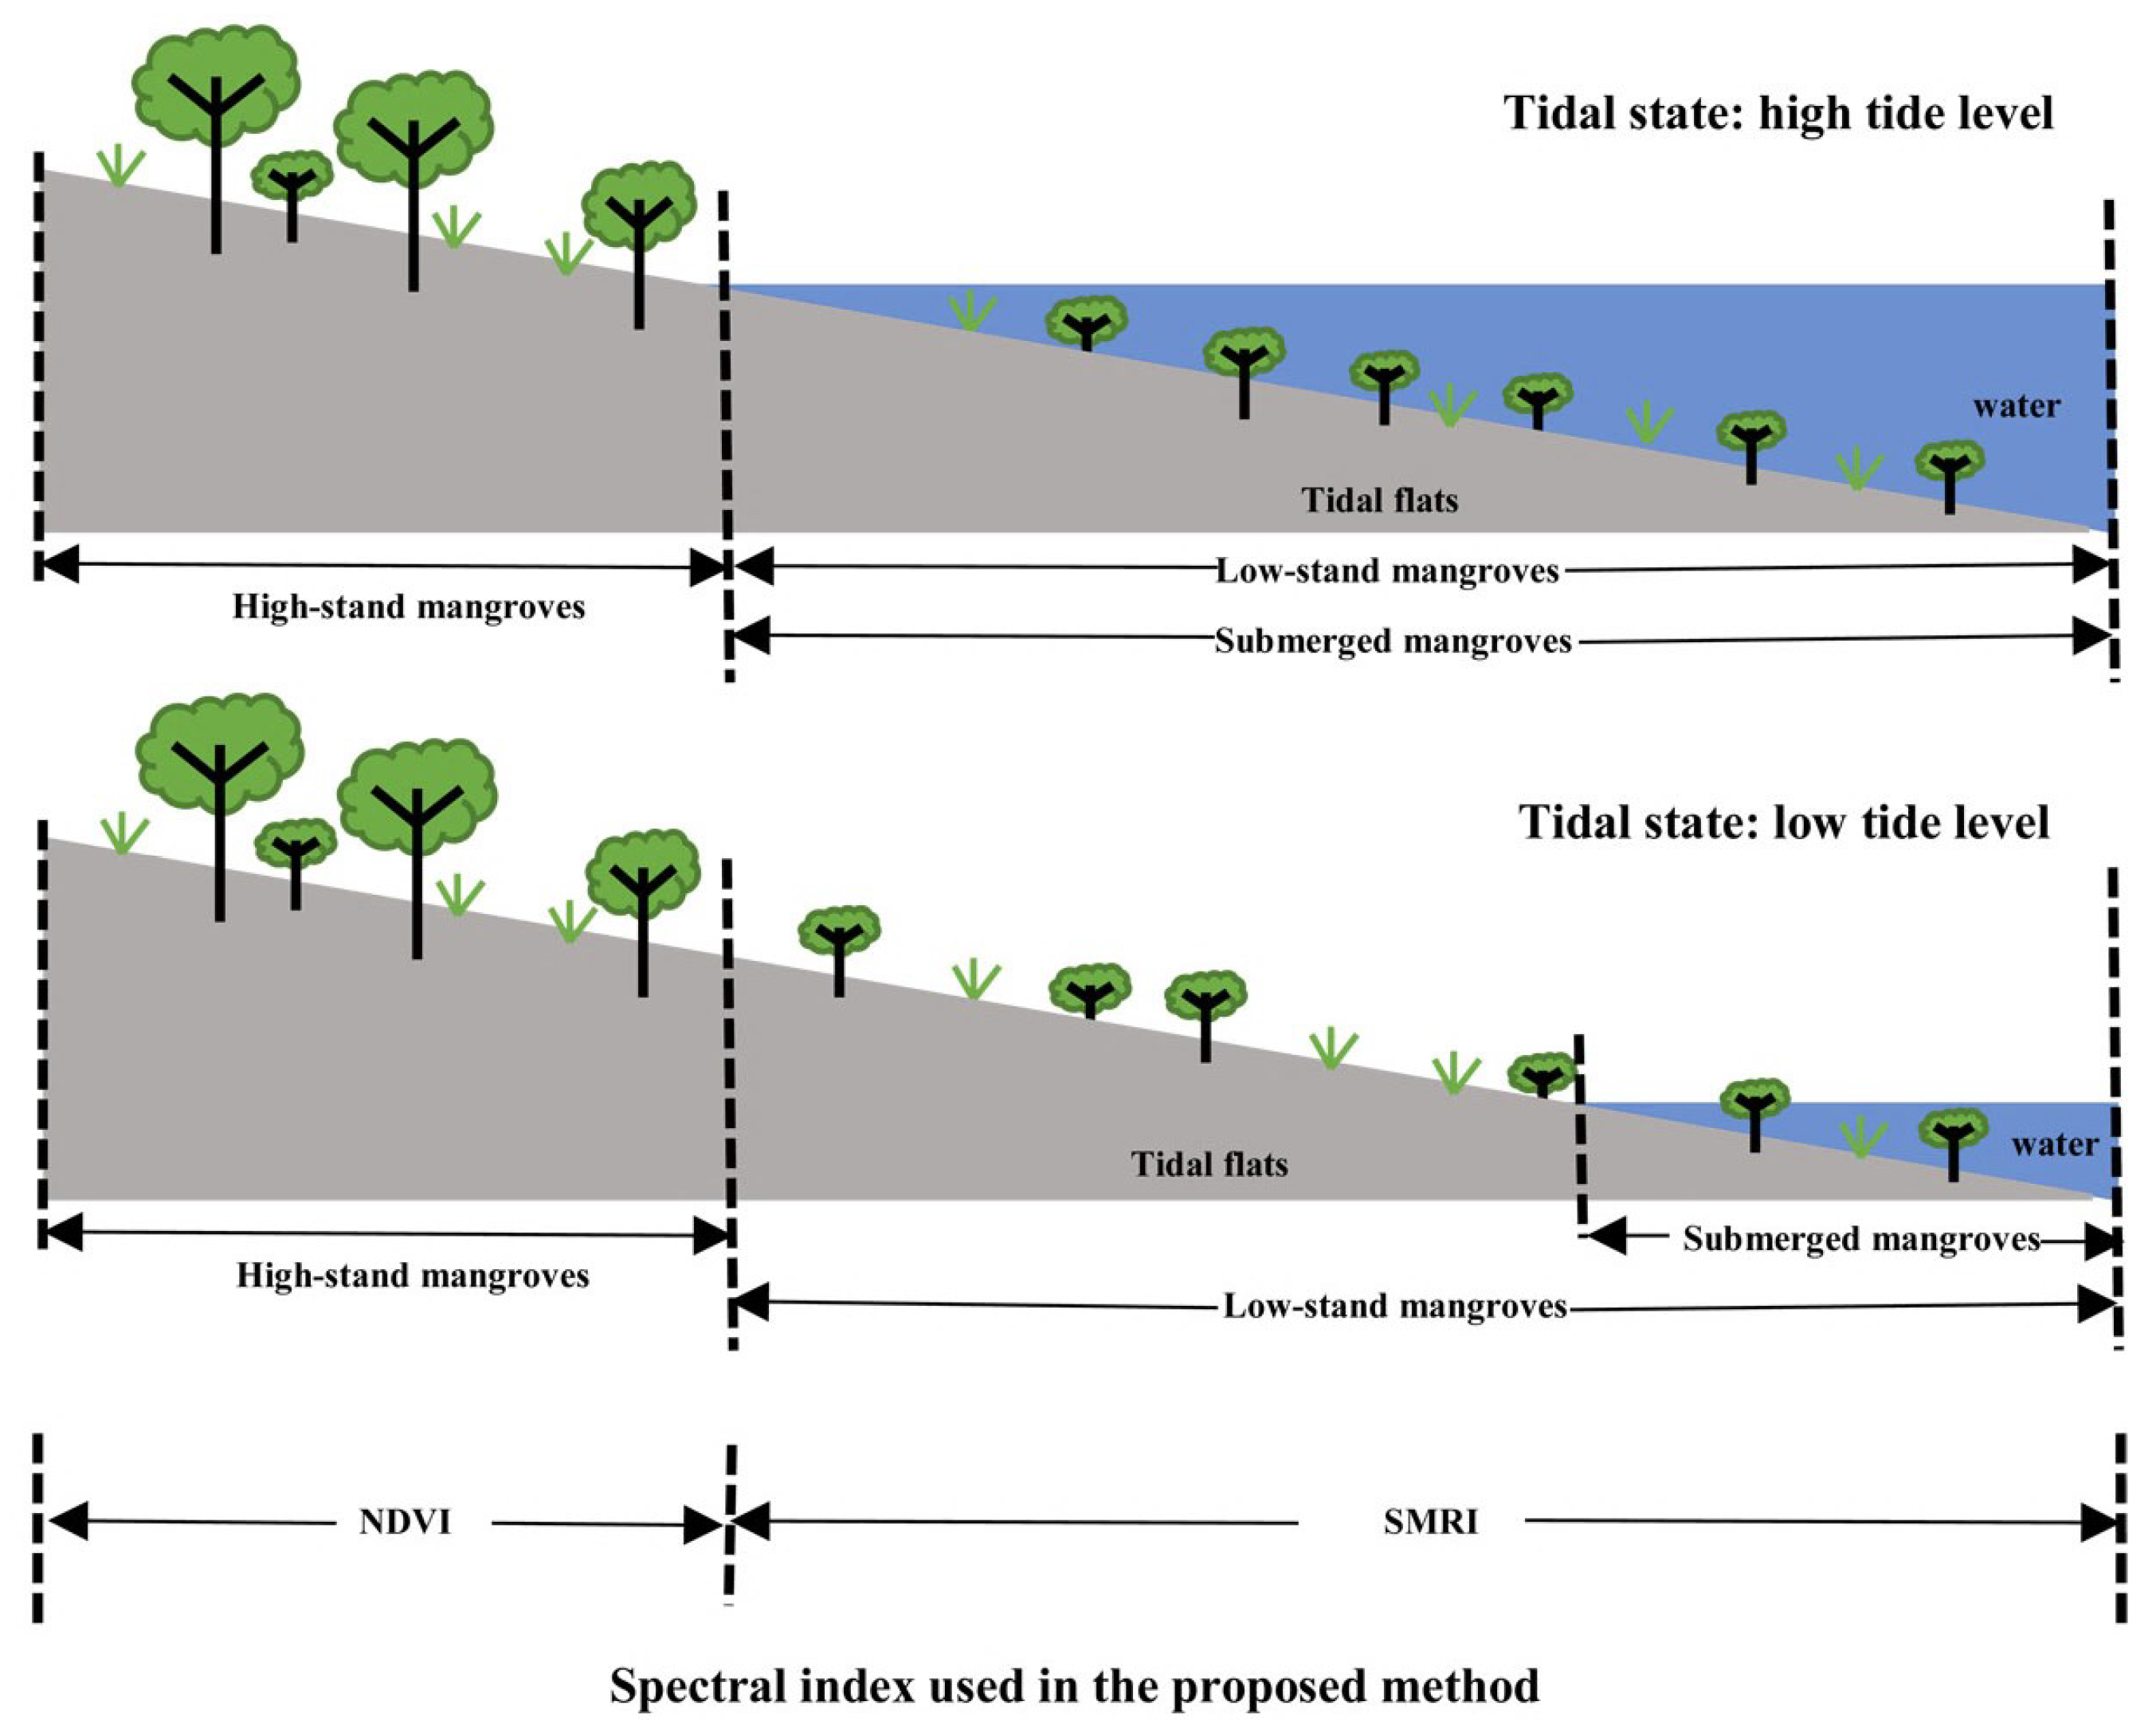

pipeline for this EOT20 data.
WHAT I'll do:
- Load all EOT20 constituents
- Interpolate tide at Mombasa; I have my shapefile for mombasa beach "mbs_beach.shp" and will use this Build 2026 time series
- Reconstruct tide signal Find lowest tide day of 2026 Plot tide height vs time of day

variables are:
- amplitude phase (in degrees) grid: lat (-90 to 90), lon (0–360)

In [25]:
#investigating the dataset amplitude
import xarray as xr

ds = xr.open_dataset(r"D:\other\4me\ocean_tides\EOT20\ocean_tides\M2_ocean_eot20.nc")

A = ds["amplitude"]

print("Ocean stats:")
print("min:", float(A.where(A > 0).mean()))
print("max:", float(A.max()))

Ocean stats:
min: 30.344215042619034
max: 496.564096760538


In [26]:
print(ds["amplitude"].isel(lat=slice(600, 700), lon=slice(300, 400)))

<xarray.DataArray 'amplitude' (lat: 100, lon: 100)> Size: 80kB
array([[      nan,       nan,       nan, ...,       nan,       nan,       nan],
       [      nan,       nan,       nan, ...,       nan,       nan,       nan],
       [      nan,       nan,       nan, ...,       nan,       nan,       nan],
       ...,
       [      nan,       nan,       nan, ..., 64.799413, 64.20562 , 63.616631],
       [      nan,       nan,       nan, ..., 64.517529, 63.918362, 63.325576],
       [      nan,       nan,       nan, ..., 64.226247, 63.623276, 63.027359]],
      shape=(100, 100))
Coordinates:
  * lat      (lat) float64 800B -15.0 -14.88 -14.75 ... -2.875 -2.75 -2.625
  * lon      (lon) float64 800B 37.5 37.62 37.75 37.88 ... 49.62 49.75 49.88
Attributes:
    units:      cm
    long_name:  Ocean tide amplitude component at M2 frequency 


Using pystac-client to query Sentinel-2 items, then for each item computing the tide at its acquisition time and accept only those with tide_height_m <= gate.

In [16]:
# pip install pystac-client pystac geopandas shapely rasterio xarray pyproj pyTMD

i query Sentinel-2 STAC for a time range

I use a STAC endpoint that actually contains Sentinel-2 Level-2A items. Common ones: Microsoft Planetary Computer, AWS Open Data, etc.
Setup AOI + ocean pixel
   
Keep the mwache existing AOI centroid (lon0, lat0) selection (Cells 2–3).
Keep gate = 0.5.

****Build valid ocean mask inside shapefile****

I now:

loop through grid
keep only points inside mwache shapefile
skip NaN cells

*sentinal 2 filtering*

For Sentinel-2 filtering,I plot the tidal regime for the whole year and highlight the dates where the tide at the Sentinel-2 overpass time (≈10:30 local time) is sufficiently low (e.g., <0.5 m). These are the days when imagery is most likely to expose intertidal habitats.

#Build valid ocean mask inside shapefile
We now:
loop through grid keep only points inside shapefile skip NaN cells

v2
For Sentinel-2 filtering, I plot the tidal regime for the whole year and highlight the dates where the tide at the Sentinel-2 overpass time (≈10:30 local time) is sufficiently low (e.g., <0.5 m). Those are the days when imagery is most likely to expose intertidal habitats.

For Sentinel-2 acquisition planning, you should not use only the M2 constituent. EOT20 is a harmonic tidal model, and the tide is reconstructed by summing all available tidal constituents.

The reconstruction equation is:

$$H(t) = \sum_{i=1}^{N} A_i \cos(\omega_i t + \phi_i)$$

**Where:**

* $A_i$ = amplitude of constituent $i$
* $\phi_i$ = phase
* $\omega_i$ = angular speed
* $N$ = number of constituents (typically 13–17 for EOT20)

This produces realistic spring-neap cycles and changing low-tide times throughout the year, which is exactly what you need for Sentinel-2 image selection.

### Workflow

```
Load AOI
   │
   ▼
Find nearest ocean pixel
   │
   ▼
Load every EOT20 constituent (M2, S2, N2, K2, K1, O1, P1, Q1, Mf, Mm, ...)
   │
   ▼
Extract amplitude & phase
   │
   ▼
Generate timestamps every 10 min
   │
   ▼
Reconstruct tide by summing ALL constituents
   │
   ▼
Extract 10:30 observations
   │
   ▼
Keep dates where tide < 0.5 m
   │
   ▼
Search Sentinel-2 images only on those dates

```

In [18]:
#testing libraries
from pyTMD.io.model import model

m = model(directory=r"D:\other\4me\ocean_tides").from_database("EOT20")

print(m)
print(m.name)
print(m.directory)
print(m.format)

pyTMD.io.model
    name: EOT20
EOT20
D:\other\4me\ocean_tides
FES-netcdf


In [20]:
#testing the data
from pyTMD.io.model import model

print(model.ocean_elevation())

#and

from pyTMD.io.model import model

m = model(directory=r"D:\other\4me\ocean_tides")
print(m)

['AODTM-5', 'AOTIM-5', 'AOTIM-5-2018', 'Arc2kmTM', 'CATS0201', 'CATS2008', 'CATS2008-v2023', 'DTU23', 'EOT20', 'FES2012', 'FES2014', 'FES2014_extrapolated', 'FES2022', 'FES2022_extrapolated', 'FES2022_native', 'GOT4.10', 'GOT4.10_SAL', 'GOT4.10_nc', 'GOT4.7', 'GOT4.8', 'GOT4.8_nc', 'GOT5.5', 'GOT5.5D', 'GOT5.5D_extrapolated', 'GOT5.5_extrapolated', 'GOT5.6', 'GOT5.6_extrapolated', 'Gr1km-v2', 'Gr1kmTM', 'HAMTIDE11', 'RE14', 'TPXO10-atlas-v2', 'TPXO10-atlas-v2-nc', 'TPXO7.2', 'TPXO8-atlas', 'TPXO8-atlas-nc', 'TPXO9-atlas', 'TPXO9-atlas-nc', 'TPXO9-atlas-v2', 'TPXO9-atlas-v2-nc', 'TPXO9-atlas-v3', 'TPXO9-atlas-v3-nc', 'TPXO9-atlas-v4', 'TPXO9-atlas-v4-nc', 'TPXO9-atlas-v5', 'TPXO9-atlas-v5-nc', 'TPXO9.1']
pyTMD.io.model
    name: None


#### pipeline:

- Setup & AOI (imports, shapefile, representative ocean point)
- Load EOT20 with pyTMD
- Predict 2025 tides during the Sentinel-2 overpass window (09:30–11:30)
- Find the minimum tide in the acquisition window for each day
- Plot annual & a month's tidal regime and highlight selected dates
- Export CSV 

In [2]:
#Cell 1 — Importing libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
#from shapely.geometry import Point #( optional)

import pyTMD


In [3]:
# =========================
# Cell 2 — Load AOI (mombasa area) and calculating centroid fro gettig representative ocean point from eot20
# =========================
shp = r"D:\other\4me\mwache\mbs_beach.shp"
gdf = gpd.read_file(shp).to_crs(4326)
geom = gdf.geometry.union_all()

centroid = geom.centroid
lon_target, lat_target = centroid.x, centroid.y
print(f"AOI Centroid: {lon_target:.4f}, {lat_target:.4f}")

AOI Centroid: 39.7481, -4.0960


In [4]:
#Cell 3 — Get Representative Ocean Point (Optimized). Find closest valid EOT20 ocean pixel
#Instead of looping through every pixel, we find the centroid of your AOI and look for the closest valid (non-NaN) ocean coordinate.import xarray as xr

# Get the centroid of your AOI
#centroid = geom.centroid
#lon_target, lat_target = centroid.x, centroid.y

# Load a single EOT20 file to map valid ocean pixels
ds = xr.open_dataset(r"D:\other\4me\ocean_tides\EOT20\ocean_tides\M2_ocean_eot20.nc")
A = ds.amplitude.values
lat_grid = ds.lat.values
lon_grid = ds.lon.values

# Create a meshgrid of coordinates and filter for valid ocean points
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
valid_mask = ~np.isnan(A)

valid_lons = lon_mesh[valid_mask]
valid_lats = lat_mesh[valid_mask]

# Find the closest valid ocean point using Euclidean distance
distances = np.sqrt((valid_lons - lon_target)**2 + (valid_lats - lat_target)**2)
closest_idx = np.argmin(distances)

lon0 = valid_lons[closest_idx]
lat0 = valid_lats[closest_idx]

print(f"AOI Centroid: {lon_target:.4f}, {lat_target:.4f}")
print(f"Closest Ocean Point: {lon0:.4f}, {lat0:.4f}")

AOI Centroid: 39.7481, -4.0960
Closest Ocean Point: 39.7500, -4.1250


#Mombasa sits virtually right on the equator, Sentinel-2 does not capture an image every day. The twin-satellite constellation features a fixed orbital repeat cycle of exactly 5 days at the equator.i.e. The Copernicus Sentinel-2 satellites pass over Mombasa approximately **73** times a year (roughly once every 5 days), always making their flyovers at approximately 10:30 AM local time (East Africa Time). https://dataspace.copernicus.eu/data-collections/copernicus-sentinel-missions/sentinel-2

Therefore, instead of a daily step model that evaluates 365 potential windows, but only a fifth of those days actually had a satellite passing overhead I simulate the actual satellite acquisitions over Mombasa across 2025.

**Getting the true count:**

In [5]:
# =========================
# Cell 4 — Inputs (gate + time settings)
# =========================
gate = 0.5  # m MLLW low-tide threshold
EAT_offset_hours = 3  # Kenya EAT = UTC+3

base_dir = r"D:\other\4me\ocean_tides"

In [6]:
# =========================
# Cell 5 — Build Sentinel-2 pass times for 2025 (10:30 EAT markers)
# =========================
start_2025 = pd.Timestamp("2025-01-01")
end_2025 = pd.Timestamp("2026-01-01")  # end-exclusive

# Sentinel-2 over Mombasa: strict 5-day schedule, marker at ~10:30 EAT
#dates_2025 = pd.date_range(start_2025, end_2025 - pd.Timedelta(days=1), freq="5D")
dates_2025 = pd.date_range(start_2025, end_2025 - pd.Timedelta(days=1))
times_eat_2025 = dates_2025 + pd.Timedelta(hours=10, minutes=30)

# Convert 10:30 EAT -> UTC for pyTMD, then use naive UTC for delta_time
times_utc_2025 = times_eat_2025 - pd.Timedelta(hours=EAT_offset_hours)
times_utc_naive_2025 = times_utc_2025.tz_localize("UTC").tz_convert("UTC").tz_localize(None)

In [7]:
# =========================
# Cell 6 — Predict tide at pass times (EOT20)
# =========================
tides_2025 = pyTMD.compute.tide_elevations(
    x=np.array([lon0]),
    y=np.array([lat0]),
    delta_time=times_utc_naive_2025.to_numpy(),
    directory=base_dir,
    model="EOT20",
    method="linear",
    extrapolate=True,
    standard="datetime",
    type="time series",
    compressed=False,
    chunks=None
).squeeze()

df_2025 = pd.DataFrame({
    "datetime": times_utc_naive_2025,  # x-axis for plotting
    "tide_height_m": tides_2025
})
df_2025["passed_gate"] = df_2025["tide_height_m"] <= gate

passed_2025 = int(df_2025["passed_gate"].sum())
failed_2025 = int((~df_2025["passed_gate"]).sum())
total_2025 = len(df_2025)
pct_2025 = 100 * passed_2025 / total_2025 if total_2025 else 0

print(f"2025: total={total_2025}, pass={passed_2025}, fail={failed_2025} ({pct_2025:.0f}%)")


2025: total=365, pass=327, fail=38 (90%)


In [8]:
# =========================
# Cell 7 — Predict hourly tide for 2025 (waveform)
# =========================
dates_hourly_2025 = pd.date_range("2025-01-01", "2025-12-31 23:00:00", freq="1h")
tide_hourly_2025 = pyTMD.compute.tide_elevations(
    x=np.array([lon0]),
    y=np.array([lat0]),
    delta_time=dates_hourly_2025.to_numpy(),
    directory=base_dir,
    model="EOT20",
    method="linear",
    extrapolate=True,
    standard="datetime",
    type="time series",
    compressed=False,
    chunks=None
).squeeze()

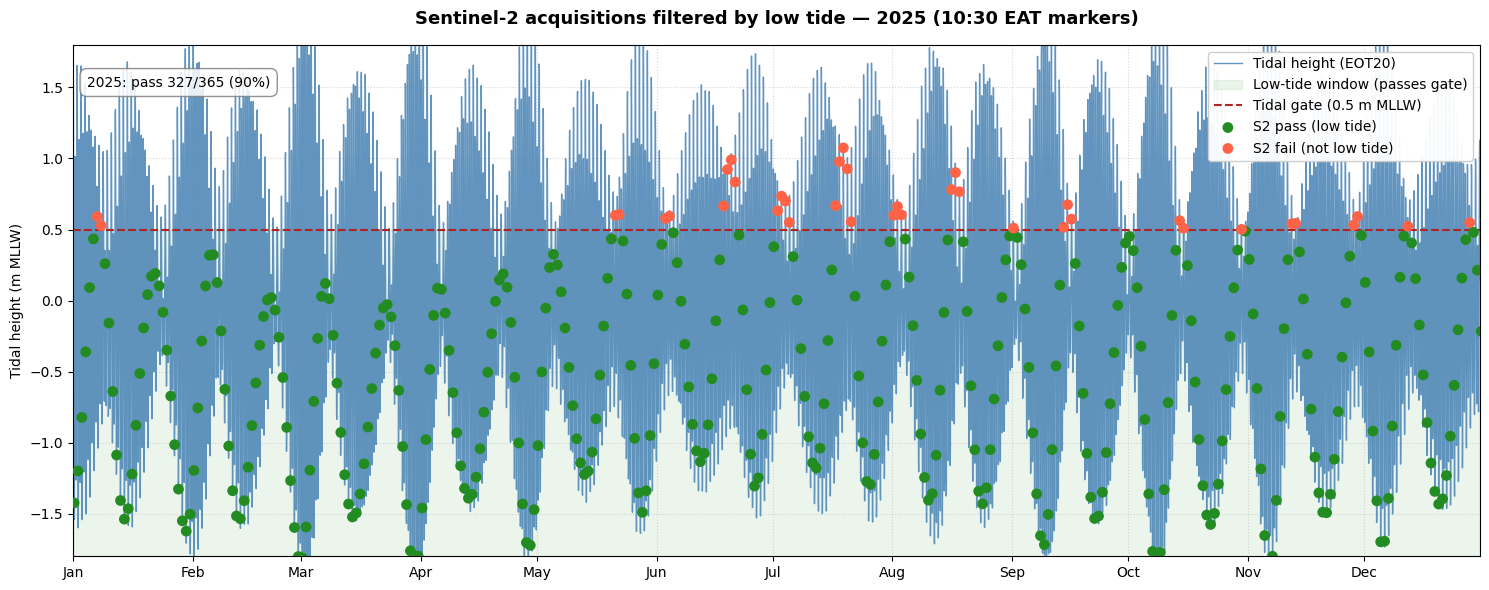

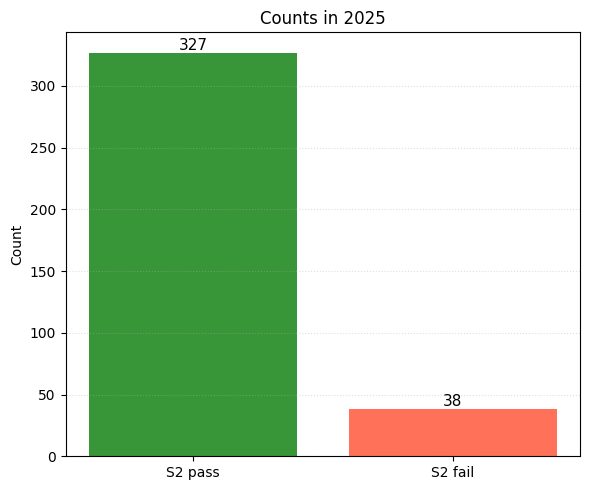

In [9]:
# =========================
# Cell 8 — Plots (waveform+markers, then separate labeled bar)
# =========================
# ---- Plot 1: waveform + markers ----
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(dates_hourly_2025, tide_hourly_2025, color="steelblue", linewidth=1, alpha=0.85, label="Tidal height (EOT20)")
ax1.axhspan(-2.0, gate, color="g", alpha=0.08, label="Low-tide window (passes gate)")
ax1.axhline(y=gate, color="firebrick", linestyle="--", linewidth=1.5, label=f"Tidal gate ({gate} m MLLW)")

ax1.scatter(df_2025.loc[df_2025["passed_gate"], "datetime"],
            df_2025.loc[df_2025["passed_gate"], "tide_height_m"],
            color="forestgreen", edgecolor="none", s=60, zorder=5, label="S2 pass (low tide)")

ax1.scatter(df_2025.loc[~df_2025["passed_gate"], "datetime"],
            df_2025.loc[~df_2025["passed_gate"], "tide_height_m"],
            color="tomato", edgecolor="none", s=60, zorder=5, label="S2 fail (not low tide)")

ax1.set_title("Sentinel-2 acquisitions filtered by low tide — 2025 (10:30 EAT markers)",
              fontsize=13, weight="bold", pad=15)
ax1.set_ylabel("Tidal height (m MLLW)")
ax1.grid(True, linestyle=":", alpha=0.5)
ax1.set_ylim(-1.8, 1.8)
ax1.set_xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

ax1.legend(loc="upper right", framealpha=0.95)
ax1.text(0.01, 0.94,
         f"2025: pass {passed_2025}/{total_2025} ({pct_2025:.0f}%)",
         transform=ax1.transAxes, fontsize=10, va="top",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="gray"))

plt.tight_layout()
plt.show()

# ---- Plot 2: separate labeled bar chart ----
fig, ax2 = plt.subplots(figsize=(6, 5))

labels = ["S2 pass", "S2 fail"]
counts = [passed_2025, failed_2025]
colors = ["forestgreen", "tomato"]

bars = ax2.bar(labels, counts, color=colors, alpha=0.9)

for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h, str(int(h)),
             ha="center", va="bottom", fontsize=11)

ax2.set_ylabel("Count")
ax2.set_title("Counts in 2025")
ax2.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()

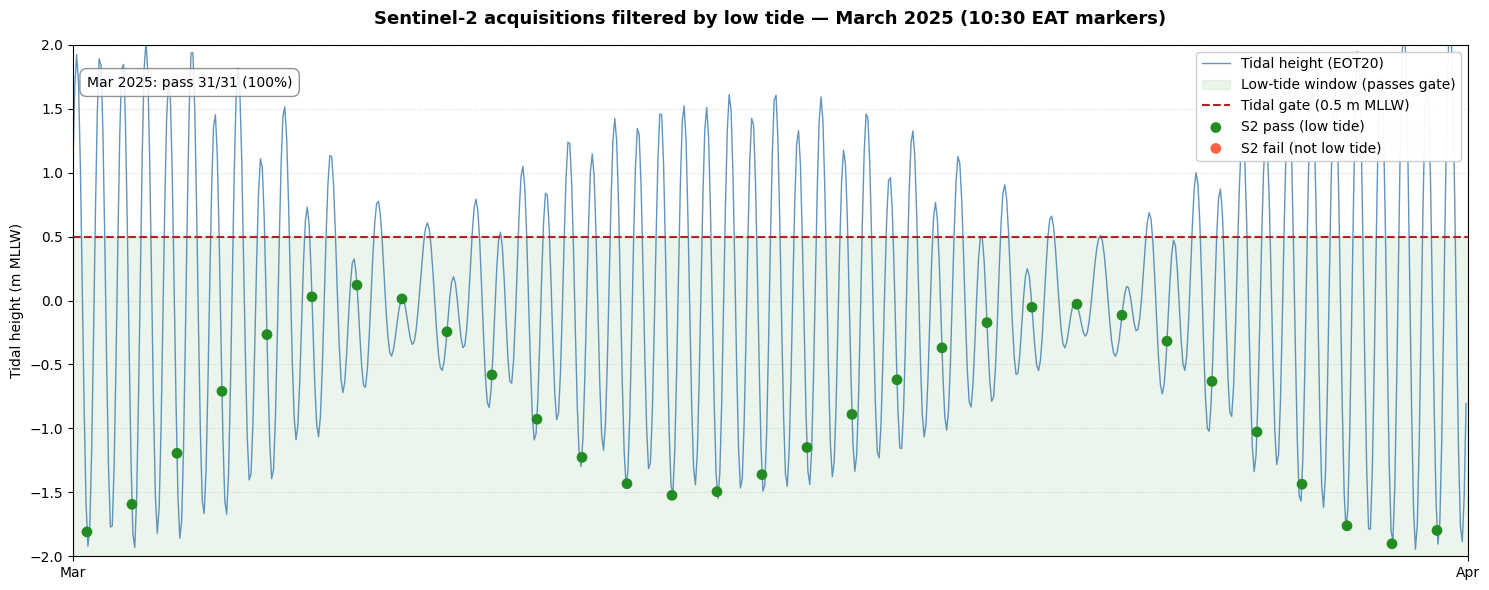

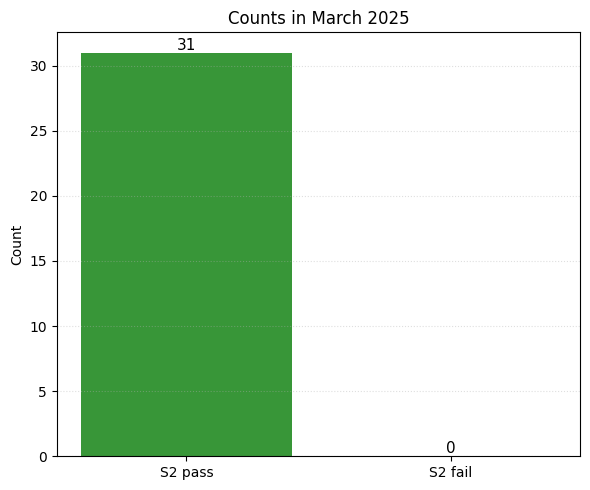

In [10]:

# =========================
# Cell 9 — Plot (for mar 2025 waveform+markers, then separate labeled bar)
# =========================

# March 2025 window
m_start = pd.Timestamp("2025-03-01")
m_end   = pd.Timestamp("2025-04-01")

df_march = df_2025[(df_2025["datetime"] >= m_start) & (df_2025["datetime"] < m_end)].copy()
dates_hourly_march = dates_hourly_2025[(dates_hourly_2025 >= m_start) & (dates_hourly_2025 < m_end)]
tide_hourly_march  = tide_hourly_2025[(dates_hourly_2025 >= m_start) & (dates_hourly_2025 < m_end)]

# Recompute pass/fail for March subset (if needed)
if "passed_gate" not in df_march.columns:
    df_march["passed_gate"] = df_march["tide_height_m"] <= gate
else:
    df_march["passed_gate"] = df_march["tide_height_m"] <= gate

total_march  = len(df_march)
passed_march = int(df_march["passed_gate"].sum())
failed_march = total_march - passed_march
pct_march = (passed_march / total_march * 100) if total_march else 0

# ---- Plot 1: waveform + markers ----
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(dates_hourly_march, tide_hourly_march,
         color="steelblue", linewidth=1, alpha=0.85, label="Tidal height (EOT20)")
ax1.axhspan(-2.0, gate, color="g", alpha=0.08, label="Low-tide window (passes gate)")
ax1.axhline(y=gate, color="firebrick", linestyle="--", linewidth=1.5,
            label=f"Tidal gate ({gate} m MLLW)")

ax1.scatter(df_march.loc[df_march["passed_gate"], "datetime"],
            df_march.loc[df_march["passed_gate"], "tide_height_m"],
            color="forestgreen", edgecolor="none", s=60, zorder=5, label="S2 pass (low tide)")

ax1.scatter(df_march.loc[~df_march["passed_gate"], "datetime"],
            df_march.loc[~df_march["passed_gate"], "tide_height_m"],
            color="tomato", edgecolor="none", s=60, zorder=5, label="S2 fail (not low tide)")

ax1.set_title("Sentinel-2 acquisitions filtered by low tide — March 2025 (10:30 EAT markers)",
              fontsize=13, weight="bold", pad=15)
ax1.set_ylabel("Tidal height (m MLLW)")
ax1.grid(True, linestyle=":", alpha=0.5)
ax1.set_ylim(-2, 2)
ax1.set_xlim(m_start, m_end)

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

ax1.legend(loc="upper right", framealpha=0.95)
ax1.text(0.01, 0.94,
         f"Mar 2025: pass {passed_march}/{total_march} ({pct_march:.0f}%)",
         transform=ax1.transAxes, fontsize=10, va="top",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="gray"))

plt.tight_layout()
plt.show()

# ---- Plot 2: separate labeled bar chart ----
fig, ax2 = plt.subplots(figsize=(6, 5))

labels = ["S2 pass", "S2 fail"]
counts = [passed_march, failed_march]
colors = ["forestgreen", "tomato"]

bars = ax2.bar(labels, counts, color=colors, alpha=0.9)

for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h, str(int(h)),
             ha="center", va="bottom", fontsize=11)

ax2.set_ylabel("Count")
ax2.set_title("Counts in March 2025")
ax2.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()




**June 2021 plot**


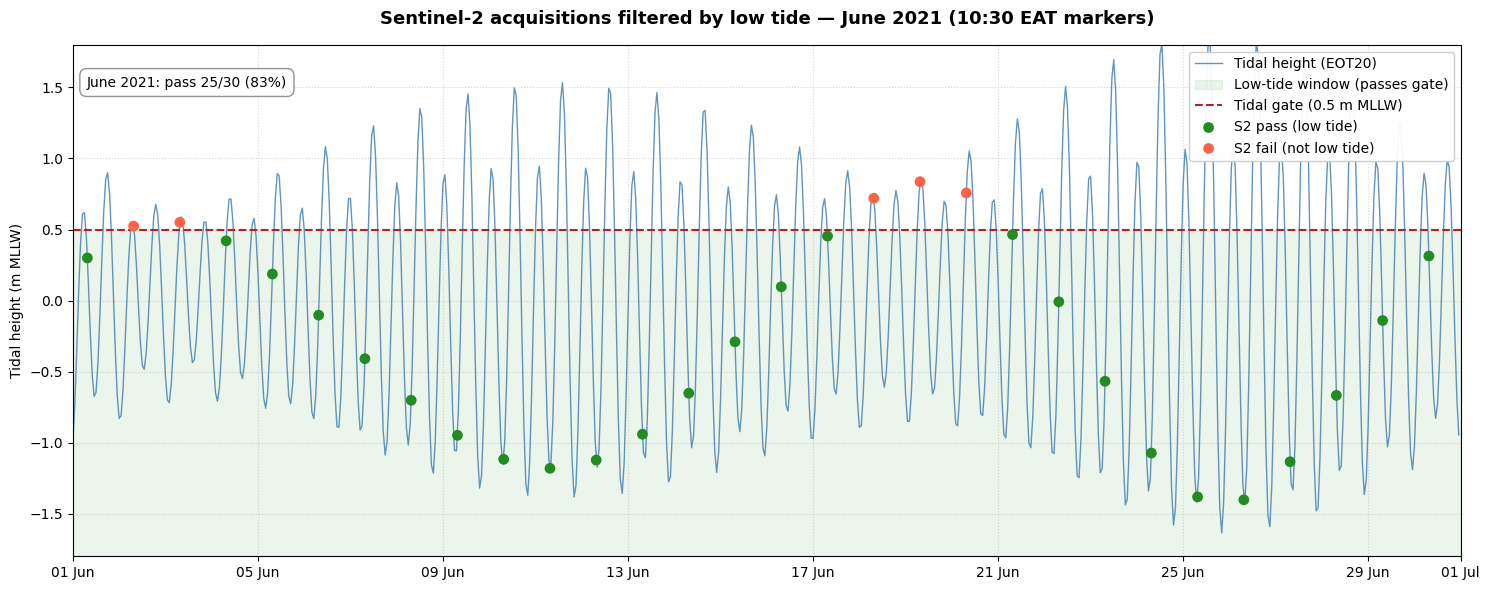

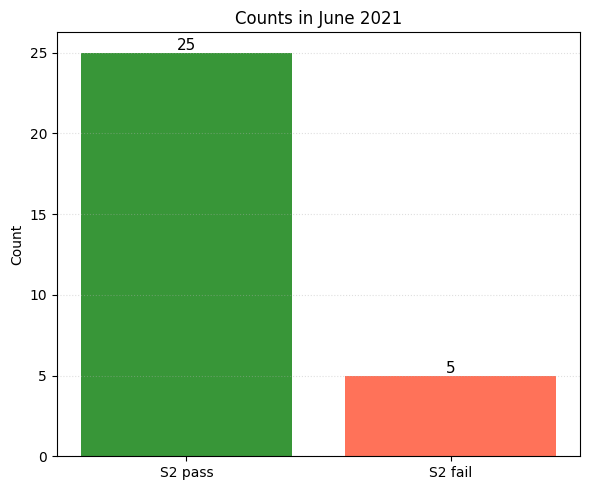

In [11]:


# --- June 2021 marker plot + separate labeled bar graph (pass vs fail) ---

gate = 0.5
EAT_offset_hours = 3  # Kenya = UTC+3

start = pd.Timestamp("2021-06-01")
end   = pd.Timestamp("2021-07-01")

dates_june = pd.date_range(start, end - pd.Timedelta(days=1))
times_eat = dates_june + pd.Timedelta(hours=10, minutes=30)
times_utc = times_eat - pd.Timedelta(hours=EAT_offset_hours)

# For pyTMD: use naive UTC datetimes
times_utc_naive = times_utc.tz_localize("UTC").tz_convert("UTC").tz_localize(None)

tides_june = pyTMD.compute.tide_elevations(
    x=np.array([lon0]),
    y=np.array([lat0]),
    delta_time=times_utc_naive.to_numpy(),
    directory=base_dir,
    model="EOT20",
    method="linear",
    extrapolate=True,
    standard="datetime",
    type="time series",
    compressed=False,
    chunks=None
).squeeze()

df_june = pd.DataFrame({
    "datetime": times_utc_naive,   # for plotting
    "tide_height_m": tides_june
})
df_june["passed_gate"] = df_june["tide_height_m"] <= gate

passed_june = int(df_june["passed_gate"].sum())
failed_june = int((~df_june["passed_gate"]).sum())
total_june = len(df_june)
pct_june = 100 * passed_june / total_june if total_june else 0

# Hourly tide for context
dates_hourly_june = pd.date_range("2021-06-01", "2021-06-30 23:00:00", freq="1h")
tide_hourly_june = pyTMD.compute.tide_elevations(
    x=np.array([lon0]),
    y=np.array([lat0]),
    delta_time=dates_hourly_june.to_numpy(),
    directory=base_dir,
    model="EOT20",
    method="linear",
    extrapolate=True,
    standard="datetime",
    type="time series",
    compressed=False,
    chunks=None
).squeeze()

# ---- Plot 1: waveform + markers ----
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(dates_hourly_june, tide_hourly_june, color="steelblue", linewidth=1, alpha=0.85, label="Tidal height (EOT20)")
ax1.axhspan(-2.0, gate, color="g", alpha=0.08, label="Low-tide window (passes gate)")
ax1.axhline(y=gate, color="firebrick", linestyle="--", linewidth=1.5, label=f"Tidal gate ({gate} m MLLW)")

ax1.scatter(df_june.loc[df_june["passed_gate"], "datetime"],
            df_june.loc[df_june["passed_gate"], "tide_height_m"],
            color="forestgreen", edgecolor="none", s=60, zorder=5, label="S2 pass (low tide)")

ax1.scatter(df_june.loc[~df_june["passed_gate"], "datetime"],
            df_june.loc[~df_june["passed_gate"], "tide_height_m"],
            color="tomato", edgecolor="none", s=60, zorder=5, label="S2 fail (not low tide)")

ax1.set_title("Sentinel-2 acquisitions filtered by low tide — June 2021 (10:30 EAT markers)", fontsize=13, weight="bold", pad=15)
ax1.set_ylabel("Tidal height (m MLLW)")
ax1.grid(True, linestyle=":", alpha=0.5)
ax1.set_ylim(-1.8, 1.8)
ax1.set_xlim(pd.Timestamp("2021-06-01"), pd.Timestamp("2021-07-01"))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax1.legend(loc="upper right", framealpha=0.95)

ax1.text(0.01, 0.94,
         f"June 2021: pass {passed_june}/{total_june} ({pct_june:.0f}%)",
         transform=ax1.transAxes, fontsize=10, va="top",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="gray"))

plt.tight_layout()
plt.show()

# ---- Plot 2: separate labeled bar chart ----
fig, ax2 = plt.subplots(figsize=(6, 5))

labels = ["S2 pass", "S2 fail"]
counts = [passed_june, failed_june]
colors = ["forestgreen", "tomato"]

bars = ax2.bar(labels, counts, color=colors, alpha=0.9)

# label bars
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h, str(int(h)),
             ha="center", va="bottom", fontsize=11)

ax2.set_ylabel("Count")
ax2.set_title("Counts in June 2021")
ax2.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()


#### Using the EOT20 dates in pystac-client to query Sentinel-2 items with acquisition dates matching the eot low tide dates.

In [12]:
# pip install pystac-client pystac geopandas shapely rasterio xarray pyproj pyTMD
from pystac_client import Client
import requests
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import shape
from pyproj import Transformer
import pyTMD


Query Sentinel-2 STAC for a time range

I use STAC endpoint that actually contains Sentinel-2 Level-2A items. Common ones: Microsoft Planetary Computer, AWS Open Data, etc.

I reuse stp2 code  *setup AOI + ocean pixel in eot workflow*

Keep existing AOI centroid (lon0, lat0).
Keep gate = 0.5.

note : 
While the exact revisit cycle from a single relative orbit path is 5 days, a ground location can often be seen by multiple different orbit tracks within the same week. Mar 2025 gives 8 Images is due to: Orbit Track Overlap: The Sentinel-2 swath width is 290 km. Because Mombasa sits near the equator, these wide swaths occasionally overlap on adjacent paths, allowing the location to be imaged by two different relative orbits instead of just one.Three-Satellite Constellation: Sentinel-2C was launched and fully integrated into operations alongside Sentinel-2A and Sentinel-2B. This significantly increased global coverage frequency beyond the original 5-day twin-satellite baseline.Calendar Math: March has 31 days. A tighter 3-to-4 day effective revisit cycle easily compounds into 8 total raw data captures over a 31-day window.

In [13]:
# Finding available sentinel images in march

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

# Example: search March 2025; change as needed
start_date = "2025-03-01"
end_date   = "2025-04-01"

# Sentinel-2 collection id commonly:
# "sentinel-2-l2a" (varies by provider)
collection = "sentinel-2-l2a"

search = catalog.search(
    collections=[collection],
    datetime=f"{start_date}/{end_date}",
    intersects=geom.__geo_interface__  # geom from your shapefile union
)

items = list(search.items())
print("Found items:", len(items))


Found items: 8



**Filter by “10:30 was low tide” (tide at acquisition time)**

keep images where the tide height at the item’s actual datetime is low.


In [14]:
# ==============================================================================
# Sentinel-2 items that PASS (tide at 10:30 EAT <= gate) using STAC (Planetary Computer)
# ==============================================================================

# ---------- Cell 1 — Imports ----------
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyTMD
from pystac_client import Client

# ---------- Cell 2 — Inputs ----------
shp = r"D:\other\4me\mwache\mbs_beach.shp"
base_dir = r"D:\other\4me\ocean_tides"
gate = 0.5  # meters MLLW

# STAC + collection
STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
COLLECTION = "sentinel-2-l2a"

# Set your range here
start_date = "2025-03-01"
end_date   = "2025-04-01"   # exclusive end
TZ_EAT = "Africa/Nairobi"   # More explicit and robust than 'Etc/GMT-3'

# ---------- Cell 3 — Load AOI and compute centroid ----------
gdf = gpd.read_file(shp).to_crs(4326)
geom = gdf.geometry.union_all()
centroid = geom.centroid
lon_target, lat_target = centroid.x, centroid.y
print(f"AOI Centroid: {lon_target:.4f}, {lat_target:.4f}")

# ---------- Cell 4 — Load representative ocean pixel ----------
# Fallback to centroid if specialized ocean pixel logic is omitted
lon0, lat0 = lon_target, lat_target
print(f"Using ocean pixel: lon0={lon0:.4f}, lat0={lat0:.4f}")

# ---------- Cell 5 — Query STAC for Sentinel-2 items ----------
catalog = Client.open(STAC_URL)

search = catalog.search(
    collections=[COLLECTION],
    datetime=f"{start_date}/{end_date}",
    intersects=geom.__geo_interface__
)

items = list(search.items())
print("STAC items found:", len(items))

if not items:
    raise ValueError("No Sentinel-2 L2A items found for the requested period/AOI.")

# Build STAC item map (id -> item)
item_map = {it.id: it for it in items}

# ---------- Cell 6 — Build acquisition table ----------
df_items = pd.DataFrame({
    "item_id": [it.id for it in items],
    "datetime_utc": [pd.to_datetime(it.datetime) for it in items],
})

# Ensure UTC-aware and convert to EAT (Africa/Nairobi)
df_items["datetime_utc"] = pd.to_datetime(df_items["datetime_utc"], utc=True)
df_items["datetime_eat"] = df_items["datetime_utc"].dt.tz_convert(TZ_EAT).dt.tz_localize(None)

# Day key in EAT as datetime64[ns] midnight
df_items["date_eat"] = df_items["datetime_eat"].dt.normalize()

print(df_items.head())

# ---------- Cell 7 — Compute tide at 10:30 EAT per day ----------
days = pd.date_range(start_date, end_date, freq="D", inclusive="left")

# 10:30 EAT converted to UTC for pyTMD
t10_eat = pd.DatetimeIndex(days.strftime("%Y-%m-%d") + " 10:30:00", tz=TZ_EAT)
t10_utc = t10_eat.tz_convert("UTC")

# pyTMD calculation using numpy datetime64
delta_time = np.array(t10_utc.to_numpy(), dtype="datetime64[us]")

tide_1030 = pyTMD.compute.tide_elevations(
    x=np.array([lon0]),
    y=np.array([lat0]),
    delta_time=delta_time,
    directory=base_dir,
    model="EOT20",
    method="linear",
    extrapolate=True,
    standard="datetime",
    type="time series",
    compressed=False,
    chunks=None
).squeeze()

# Build daily results table
df_days = pd.DataFrame({
    "date_eat": pd.DatetimeIndex(days).normalize(),
    "tide_1030_m": tide_1030
})
df_days["passed_gate"] = df_days["tide_1030_m"] <= gate

print(df_days.head())
print(f"Passed days: {int(df_days['passed_gate'].sum())} of {len(df_days)}")

# ---------- Cell 8 — Pick nearest acquisition to 10:30 EAT per EAT day ----------
target_1030_eat = df_items["date_eat"] + pd.Timedelta(hours=10.5)
df_items["diff_sec_to_1030"] = (df_items["datetime_eat"] - target_1030_eat).abs().dt.total_seconds()

df_nearest = (
    df_items
    .sort_values(["date_eat", "diff_sec_to_1030"])
    .groupby("date_eat", as_index=False)
    .head(1)
    .copy()
)

# Merge gate status
df_result = df_nearest.merge(df_days, on="date_eat", how="left")

print(f"Nearest acquisitions: {len(df_result)}")
print(f"Passed acquisitions: {int(df_result['passed_gate'].sum())}")
print(f"Failed acquisitions: {int((~df_result['passed_gate']).sum())}")

df_pass = df_result[df_result["passed_gate"]].copy()

# ---------- Cell 9 — Create the list of PASS images ----------
records = []

for it_id in df_pass["item_id"].tolist():
    it = item_map[it_id]
    acq_time_utc = pd.to_datetime(it.datetime, utc=True)
    acq_time_eat = acq_time_utc.tz_convert(TZ_EAT)
    
    # Calculate exact hour offset from target 10:30 AM gate metric
    target_gate_time = acq_time_eat.normalize() + pd.Timedelta(hours=10.5)
    hours_from_gate = abs((acq_time_eat.tz_localize(None) - target_gate_time.tz_localize(None)).total_seconds()) / 3600.0

    # Cleaned up cloud cover extraction
    cc = it.properties.get("eo:cloud_cover", it.properties.get("s2:cloud_cover", None))

    records.append({
        "item_id": it.id,
        "image_date": acq_time_utc.date(),
        "image_time_utc": acq_time_utc,
        "image_time_eat": acq_time_eat,
        "hours_from_1030_gate": round(hours_from_gate, 2),
        "cloud_cover": cc,
        "product": it.properties.get("productIdentifier", it.id)
    })

if records:
    images_df_pass = pd.DataFrame(records).sort_values(["hours_from_1030_gate", "cloud_cover"])
    display(images_df_pass[[
        "item_id",
        "image_date",
        "image_time_utc",
        "image_time_eat",
        "hours_from_1030_gate",
        "cloud_cover",
        "product"
    ]])
else:
    print("No PASS items found for this range/AOI/gate.")

# ---------- Cell 10 — (Optional) Access imagery asset hrefs ----------
if not df_pass.empty:
    first_id = df_pass["item_id"].iloc[0]
    first_item = item_map[first_id]
    print(f"\nExample asset layout for item {first_id}:")
    print(list(first_item.assets.keys())[:5], "... and more.")

AOI Centroid: 39.7481, -4.0960
Using ocean pixel: lon0=39.7481, lat0=-4.0960
STAC items found: 8
                                             item_id  \
0  S2B_MSIL2A_20250330T072619_R049_T37MER_2025033...   
1  S2A_MSIL2A_20250327T074431_R049_T37MER_2025032...   
2  S2C_MSIL2A_20250325T072641_R049_T37MER_2025032...   
3  S2B_MSIL2A_20250320T072619_R049_T37MER_2025032...   
4  S2A_MSIL2A_20250317T073021_R049_T37MER_2025031...   

                      datetime_utc            datetime_eat   date_eat  
0 2025-03-30 07:26:19.024000+00:00 2025-03-30 10:26:19.024 2025-03-30  
1 2025-03-27 07:44:31.024000+00:00 2025-03-27 10:44:31.024 2025-03-27  
2 2025-03-25 07:26:41.025000+00:00 2025-03-25 10:26:41.025 2025-03-25  
3 2025-03-20 07:26:19.024000+00:00 2025-03-20 10:26:19.024 2025-03-20  
4 2025-03-17 07:30:21.024000+00:00 2025-03-17 10:30:21.024 2025-03-17  
    date_eat  tide_1030_m  passed_gate
0 2025-03-01    -1.809485         True
1 2025-03-02    -1.593926         True
2 2025-03-03    -

,item_id,image_date,image_time_utc,image_time_eat,hours_from_1030_gate,cloud_cover,product
3,S2A_MSIL2A_20250317T073021_R049_T37MER_2025031...,2025-03-17,2025-03-17 07:30:21.024000+00:00,2025-03-17 10:30:21.024000+03:00,0.01,18.914333,S2A_MSIL2A_20250317T073021_R049_T37MER_2025031...
0,S2C_MSIL2A_20250305T072821_R049_T37MER_2025030...,2025-03-05,2025-03-05 07:28:21.025000+00:00,2025-03-05 10:28:21.025000+03:00,0.03,24.080637,S2C_MSIL2A_20250305T072821_R049_T37MER_2025030...
2,S2C_MSIL2A_20250315T072711_R049_T37MER_2025031...,2025-03-15,2025-03-15 07:27:11.025000+00:00,2025-03-15 10:27:11.025000+03:00,0.05,28.592023,S2C_MSIL2A_20250315T072711_R049_T37MER_2025031...
5,S2C_MSIL2A_20250325T072641_R049_T37MER_2025032...,2025-03-25,2025-03-25 07:26:41.025000+00:00,2025-03-25 10:26:41.025000+03:00,0.06,27.322730,S2C_MSIL2A_20250325T072641_R049_T37MER_2025032...
4,S2B_MSIL2A_20250320T072619_R049_T37MER_2025032...,2025-03-20,2025-03-20 07:26:19.024000+00:00,2025-03-20 10:26:19.024000+03:00,0.06,51.422817,S2B_MSIL2A_20250320T072619_R049_T37MER_2025032...
7,S2B_MSIL2A_20250330T072619_R049_T37MER_2025033...,2025-03-30,2025-03-30 07:26:19.024000+00:00,2025-03-30 10:26:19.024000+03:00,0.06,84.414333,S2B_MSIL2A_20250330T072619_R049_T37MER_2025033...
1,S2B_MSIL2A_20250310T072629_R049_T37MER_2025031...,2025-03-10,2025-03-10 07:26:29.024000+00:00,2025-03-10 10:26:29.024000+03:00,0.06,92.874265,S2B_MSIL2A_20250310T072629_R049_T37MER_2025031...
6,S2A_MSIL2A_20250327T074431_R049_T37MER_2025032...,2025-03-27,2025-03-27 07:44:31.024000+00:00,2025-03-27 10:44:31.024000+03:00,0.24,45.596325,S2A_MSIL2A_20250327T074431_R049_T37MER_2025032...



Example asset layout for item S2C_MSIL2A_20250305T072821_R049_T37MER_20250305T110513:
['AOT', 'B01', 'B02', 'B03', 'B04'] ... and more.


### sentinel data and indices in gee

### indices relevant in monitoring the mangrove ecosysytem

#### i. Optical Spectral Indices

##### NDVI (Normalized Difference Vegetation Index)

* **Definition:** Measures chlorophyll absorption and structural canopy reflectance using Red and Near-Infrared (NIR) bands:

$$\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$


* **Mangrove Relevance:** Acts as the fundamental global baseline indicator for mapping multi-temporal mangrove distribution, extent changes, and carbon flux tracking (Chaquime dos Santos, 2025). However, it frequently encounters saturation barriers in dense, closed-canopy subtropical mangrove forests.

##### NDWI (Normalized Difference Water Index)

* **Definition:** Accentuates liquid water and open water features using Green and NIR bands:

$$\text{NDWI} = \frac{\text{Green} - \text{NIR}}{\text{Green} + \text{NIR}}$$


* **Mangrove Relevance:** Essential for water body delineation and coastal wetland mapping, serving to isolate intertidal mudflats and tidal flooding regimes from neighboring land surfaces (Agarwal, 2026; Zhijie et al., 2025).

##### EVI (Enhanced Vegetation Index)

* **Definition:** An optimized vegetation index incorporating Blue, Red, and NIR bands to adjust for atmospheric aerosols and soil background reflectance noise.
* **Mangrove Relevance:** Particularly valuable in dense tropical and subtropical mangrove systems because it maintains sensitivity across high-leaf-area zones where NDVI saturates, making it optimal for precise biomass, canopy health, and structural productivity modeling (Zhijie et al., 2025).

##### LSWI (Land Surface Water Index)

* **Definition:** Calculates vegetation canopy and soil moisture dynamics using a normalized ratio of NIR and Shortwave Infrared (SWIR) bands:

$$\text{LSWI} = \frac{\text{NIR} - \text{SWIR}}{\text{NIR} + \text{SWIR}}$$


* **Mangrove Relevance:** Capable of tracking both internal plant moisture and high-frequency tidal inundation beneath the forest canopy, facilitating accurate discrimination between true mangroves and dry terrestrial forests.

##### NDRE (Normalized Difference Red Edge)

* **Definition:** A variation of the traditional normalized vegetation index that replaces the standard Red band with the Red Edge band.
* **Mangrove Relevance:** Leverages the specialized Red Edge bands (such as those on Sentinel-2) to capture distinct structural and chemical changes, which are vital for distinguishing diverse coastal tree species within complex coastal wetland frameworks (Li, 2026; Novanda et al., 2024).

##### CIRE (Chlorophyll Index Red Edge)

* **Definition:** Synthesizes the relationship between the NIR and Red Edge bands to linearize the estimation of total canopy chlorophyll:

$$\text{CIRE} = \left(\frac{\text{NIR}}{\text{Red Edge}}\right) - 1$$


* **Mangrove Relevance:** Shows high sensitivity to variation in leaf pigment concentrations and nitrogen content, proving useful for assessing mangrove physiological degradation, environmental stress levels, and canopy structural health (Novanda et al., 2024).

##### MVI (Mangrove Vegetation Index)

* **Definition:** A customized, specialized spectral index designed to isolate the collective greenness and moisture properties of mangroves using Green, NIR, and SWIR bands:

$$\text{MVI} = \frac{|\text{NIR} - \text{Green}|}{|\text{SWIR} - \text{Green}|}$$

* **Mangrove Relevance:** Explicitly addresses mixed-pixel issues in tidal zones, establishing a distinct spectral threshold to isolate mangroves from upland forests or urban footprints without needing intricate, tide-synchronized masking steps (Zhijie et al., 2025).

##### NDMI (Normalized Difference Moisture Index)

* **Definition:** Utilizes the contrast between NIR and SWIR bands to observe changes in canopy liquid water content.
* **Mangrove Relevance:** Tracks spatial patterns of vegetation water stress and ecosystem health degradation over time, serving as a reliable metric for indexing baseline forest wellness or drought-induced dieback (Wei et al., 2025).

---

#### ii. Synthetic Aperture Radar (SAR) Metrics

##### VV (Vertical-Transmit, Vertical-Receive)

* **Definition:** Co-polarized C-band radar backscatter interacting on a single vertical alignment.
* **Mangrove Relevance:** Captures structural interactions along vertical landscape geometries. It responds strongly to erect tree trunks, upright stems, and exposed prop-root networks interacting with tidal backdrops (Li, 2026).

##### VH (Vertical-Transmit, Horizontal-Receive)

* **Definition:** Cross-polarized radar backscatter where the transmitted energy changes polarization orientation upon surface interaction.
* **Mangrove Relevance:** Driven heavily by volume scattering within leafy, multi-layered canopies. It serves as a core remote sensing parameter for estimating mangrove above-ground biomass (AGB), tracking forest degradation, and separating mangrove structures from flat land or open water (Xu et al., 2026).

##### VV/VH Ratio

* **Definition:** A dual-polarization cross-ratio calculated from co-polarized and cross-polarized radar components.
* **Mangrove Relevance:** Normalizes background errors caused by shifting environmental conditions (such as wind-induced tidal waves or variable soil moisture), allowing for more consistent mapping of forest structure, localized biomass levels, and species zonation (Xu et al., 2026).

---
####Deriving **Mangrove Extent** and then calculating **Above-Ground Biomass (AGB)** requires a two-step hierarchical remote sensing pipeline. You must accurately map the footprint *first* to avoid predicting forest biomass on inland forests, coconut plantations, or intertidal mudflats.

A streamlined workflow involves combining the specific spectral and radar indices.

---

## Phase 1: Deriving Mangrove Extent (The Binary Mask)

The goal here is to create a clean, strict **"Mangrove vs. Non-Mangrove"** mask.

### Step 1: Feature Stack Creation

Load your satellite imagery (e.g., Sentinel-2 and Sentinel-1) and calculate three strategic indices:

* **`MVI` (Mangrove Vegetation Index):** Safely isolates the combined green-moisture signature unique to mangroves.
* **`NDVI` or `EVI`:** Filters out non-vegetated areas (water, mudflats, sandbars).
* **`LSWI` or `NDWI`:** Detects the high-moisture intertidal background, separating mangroves from dry, upland terrestrial forests.

### Step 2: Spatial Classification

You have two options to separate the data based on your processing environment:

1. **Thresholding (Rapid):** Apply a strict threshold directly to the MVI layer. Generally, pixels where $\text{MVI} > 4.5$ (sensor-dependent) isolate mangroves reliably.
2. **Machine Learning (Highly Accurate):** Collect training points for "Mangrove" and "Other" (water, urban, terrestrial forest). Feed your index stack (`MVI`, `EVI`, `LSWI`, `VH`) into a **Random Forest (RF)** classifier inside Google Earth Engine (GEE).

> **Output:** A binary raster layer where **1 = Mangrove** and **0 = Background**. Clip all subsequent data to this mask.

---

## Phase 2: Estimating Above-Ground Biomass (AGB)

Because optical data suffers from saturation, you must lean heavily on SAR metrics to model the 3D volume of the masked forest.

```
       [ Optical Stack: EVI, NDRE ]   +   [ SAR Stack: VH, VV/VH ]
                                    │
                                    ▼
                       [ Random Forest Regression ] 
                                    │
                        ◀───( Calibrated by )───▶ [ In-situ Plots / UAV-LiDAR ]
                                    │
                                    ▼
                         [ Pixel-level AGB Map ]

```

### Step 1: Collect Calibration Data (Ground Truth)

You cannot map biomass with satellite data alone; it must be calibrated with true values.

* **In-situ Plots:** Gather field inventory data (Diameter at Breast Height ($DBH$), tree height ($H$), and species wood density ($\rho$)). Convert these to biomass ($\text{Mg/ha}$) using regional allometric equations (e.g., Chave's pantropical equation).
* **UAV-LiDAR (Alternative):** If ground access is restricted, drone-based LiDAR can extract Canopy Height Models (CHM) to calculate structural volume over sample strips.

### Step 2: Build the Remote Sensing Predictor Stack

Extract the following underlying values exclusively for your masked mangrove pixels:

* **`VH` backscatter:** Your primary predictor. Tracks canopy volume, branch complexity, and leaf mass.
* **`VV/VH Ratio`:** Normalizes errors introduced by varying soil moisture and tidal levels under the trees.
* **`EVI`:** Extracted from the optical data to capture canopy greenness and variations in leaf area index without immediate saturation.
* **`NDRE` or `CIRE`:** Captures variations in canopy chlorophyll, assisting the model in distinguishing high-biomass tall zones from dense, low-biomass stunted shrub mangroves.

### Step 3: Train a Regression Model

1. Link your field plot GPS coordinates to the matching pixel values in your predictor stack.
2. Train a **Machine Learning Regressor** (Random Forest Regression or Support Vector Regression are standard selections). The model learns how variations in `VH` decibels and `EVI` values correspond to physical tons of biomass.
3. Validate the model using a split-sample approach (e.g., 70% training, 30% validation) to calculate the $R^2$ coefficient and Root Mean Square Error (RMSE).

### Step 4: Spatial Upscaling

Apply the validated regression model across your entire Phase 1 mangrove mask.

> **Final Output:** A continuous map where each pixel represents the localized Above-Ground Biomass density (typically expressed in Megagrams per Hectare, $\text{Mg/ha}$, or tons/ha). By multiplying the pixel area by the density values, you can sum the total blue carbon stock for your entire study site.


---

#### References

Agarwal, A. (2026). Image processing and AI techniques for climate change detection using remote sensing: A comprehensive review. *Frontiers in Artificial Intelligence*, *9*, Article 1814362.

Chaquime dos Santos, A. B. (2025). Global trends in vegetation carbon stock monitoring using Google Earth Engine and NDVI: A systematic review. *OPUS Universität Augsburg*, 1–35.

Li, H. (2026). Multi-temporal fusion of Sentinel-1 and Sentinel-2 data for high-accuracy tree species identification in subtropical regions. *Remote Sensing*, *18*(4), 592.

Novanda, I. G. A., Setiawati, M. D., & Sugiana, I. P. (2024). Vegetation index comparison for estimating above-ground carbon (Cag) in mangrove forests using Sentinel-2 imagery: Case study from West Bali, Indonesia. *Environments*, *5*(3), 33.

Wei, S., et al. (2025). A review of mangrove degradation assessment using remote sensing: Advances, challenges, and opportunities. *GIScience & Remote Sensing*, *62*(1), 2491920.

Xu, C., et al. (2026). Enhanced estimation of crop biomass and height using Sentinel-1 polarization texture indices and integration with optical remote sensing. *International Journal of Digital Earth*, *19*(1), 2616988.

Zhijie, X., et al. (2025). Monitoring the annual dynamics of mangrove forests in the Guangxi Beibu Gulf of China from 2000 to 2023 via the SNIC-RF algorithm using the GEE platform. *International Journal of Digital Earth*, *18*(1), 2558920.

#### indices remove: ndmi,lswi, ndwi # good for Canopy Moisture & Substrate Saturation

In [15]:
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# =========================================================================
# 1. Ingest, Clean, and Format local AOI Shapefile
# =========================================================================
shp_path = r"D:\other\4me\mwache\mwache_mangroves_400m_buffer_v3.shp"
gdf = gpd.read_file(shp_path)

if gdf.crs is None:
    raise ValueError("Shapefile has no CRS defined")

gdf = gdf.to_crs(epsg=4326)
gdf["geometry"] = gdf.buffer(0)
gdf = gdf.dissolve()
gdf = gdf.reset_index(drop=True)

print("--- Local GeoDataFrame Sanity Checks ---")
print(gdf.head())
print(gdf.geom_type.value_counts())

# =========================================================================
# 2. Authenticate and Initialize Earth Engine
# =========================================================================
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

aoi = geemap.gdf_to_ee(gdf)

# =========================================================================
# 3. Extract Unique Calendar Dates from Validated Python Dataframe
# =========================================================================
passed_dates = pd.to_datetime(images_df_pass["image_date"]).dt.strftime('%Y-%m-%d').unique().tolist()

print("\n--- GEE Query Profile ---")
print(f"Targeting Low-Tide Image Dates: {passed_dates}")

# 1-day step increments for exact target low-tide optical days
date_filters = [ee.Filter.date(d, ee.Date(d).advance(1, 'day')) for d in passed_dates]
optical_date_filter = ee.Filter.Or(*date_filters) if date_filters else ee.Filter.date(start_date, end_date)

# =========================================================================
# 4. Pull and Process Sentinel-2 Optical Collection
# =========================================================================
s2_collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterBounds(aoi).filter(optical_date_filter)

def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start", "system:index"])

def compute_optical_indices(image):
    blue  = image.select('B2')
    green = image.select('B3')
    red   = image.select('B4')
    re1   = image.select('B5')  
    re3   = image.select('B7')  
    nir   = image.select('B8')  
    swir1 = image.select('B11') 
    
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    
    evi = image.expression('2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
        {'NIR': nir, 'RED': red, 'BLUE': blue}
    ).rename('EVI')
    
    ndre = image.normalizedDifference(['B7', 'B5']).rename('NDRE')
    cire = image.expression('(RE3 / RE1) - 1', {'RE3': re3, 'RE1': re1}).rename('CIRE')
    mvi = image.expression('(NIR - GREEN) / (SWIR1 - GREEN)', {'NIR': nir, 'GREEN': green, 'SWIR1': swir1}).rename('MVI')

    return image.addBands([ndvi, evi, ndre, cire, mvi])

clean_s2 = s2_collection.map(mask_s2_clouds).map(compute_optical_indices)
s2_composite = clean_s2.median()

# =========================================================================
# 5. Pull and Process Sentinel-1 SAR Radar Collection (Focused Month Window)
# =========================================================================
# Restrict window around the active list of dates (5 days before earliest, 5 days after latest)
if passed_dates:
    sorted_dates = sorted(passed_dates)
    s1_start = ee.Date(sorted_dates[0]).advance(-5, 'day')
    s1_end = ee.Date(sorted_dates[-1]).advance(5, 'day')
else:
    s1_start = ee.Date(start_date)
    s1_end = ee.Date(end_date)

s1_collection = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(aoi)
    .filterDate(s1_start, s1_end)
)

s1_count = s1_collection.size().getInfo()
s2_count = clean_s2.size().getInfo()

print(f"Matched {s2_count} Sentinel-2 Optical frames on exact low-tide dates.")
print(f"Matched {s1_count} Sentinel-1 SAR Radar frames over the tight target window.")

# Setup structure map layers if any radar footprints exist in this window
has_sar = s1_count > 0
if has_sar:
    sample_bands = s1_collection.first().bandNames().getInfo()
    print(f"Available SAR Bands in area footprint: {sample_bands}")
    
    if 'VV' in sample_bands and 'VH' in sample_bands:
        def compute_sar_metrics(image):
            vv = image.select('VV')
            vh = image.select('VH')
            vv_raw = ee.Image.constant(10).pow(vv.divide(10))
            vh_raw = ee.Image.constant(10).pow(vh.divide(10))
            ratio = vv_raw.divide(vh_raw).log10().multiply(10).rename('vv_vh_ratio')
            return image.addBands([ratio])
        
        processed_s1 = s1_collection.map(compute_sar_metrics)
        s1_composite = processed_s1.median().select(['VV', 'VH', 'vv_vh_ratio'])
    elif 'VV' in sample_bands:
        print("Warning: Only 'VV' channel available. 'VH' and ratio outputs skipped.")
        s1_composite = s1_collection.median().select(['VV'])
    elif 'HH' in sample_bands and 'HV' in sample_bands:
        print("Detected alternative 'HH'/'HV' polarization format. Processing ratio...")
        def compute_hh_hv_metrics(image):
            hh = image.select('HH')
            hv = image.select('HV')
            hh_raw = ee.Image.constant(10).pow(hh.divide(10))
            hv_raw = ee.Image.constant(10).pow(hv.divide(10))
            ratio = hh_raw.divide(hv_raw).log10().multiply(10).rename('vv_vh_ratio')
            return image.addBands([ratio]).rename({'HH': 'VV', 'HV': 'VH', 'vv_vh_ratio': 'vv_vh_ratio'})
            
        processed_s1 = s1_collection.map(compute_hh_hv_metrics)
        s1_composite = processed_s1.median().select(['VV', 'VH', 'vv_vh_ratio'])
    else:
        has_sar = False

# =========================================================================
# 6. Merge Datasets
# =========================================================================
if s2_count == 0:
    raise ValueError("The Sentinel-2 stack returned 0 frames. Check geometry bounds or date criteria.")

if has_sar:
    final_composite = s2_composite.addBands(s1_composite).clip(aoi)
else:
    print("Zero valid radar configurations found within focused month. Compiling Optical stack ONLY.")
    final_composite = s2_composite.clip(aoi)

# =========================================================================
# 7. Create Interactive Geemap Visualizations
# =========================================================================
Map = geemap.Map()
Map.center_object(aoi, zoom=13)

# Base Optical Overlays
Map.add_layer(final_composite, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.25}, 'True Color (RGB)')
#Map.add_layer(final_composite, {'bands': ['B8', 'B4', 'B3'], 'min': 0, 'max': 0.4}, 'False Color Infrared', False)

# Standard Structural Analytics
Map.add_layer(final_composite.select('NDVI'), {'min': 0.1, 'max': 0.8, 'palette': ['blue', 'yellow', 'green']}, 'NDVI', False)
Map.add_layer(final_composite.select('EVI'), {'min': 0.1, 'max': 0.8, 'palette': ['blue', 'yellow', 'darkgreen']}, 'EVI', False)

# Advanced Red-Edge Analytics
Map.add_layer(final_composite.select('NDRE'), {'min': 0, 'max': 0.5, 'palette': ['purple', 'yellow', 'green']}, 'NDRE', False)
Map.add_layer(final_composite.select('CIRE'), {'min': 0, 'max': 4.0, 'palette': ['blue', 'purple', 'orange']}, 'CIRE', False)

# Mangrove Index Layer
Map.add_layer(final_composite.select('MVI'), {'min': 2, 'max': 15, 'palette': ['white', 'orange', 'purple']}, 'Mangrove Vegetation Index (MVI)')

# Active Microwave Radar Backscatter Layers
if has_sar:
    available_output_bands = final_composite.bandNames().getInfo()
    if 'VV' in available_output_bands:
        Map.add_layer(final_composite.select('VV'), {'min': -18, 'max': -4}, 'SAR VV Backscatter (dB)', False)
    if 'VH' in available_output_bands:
        Map.add_layer(final_composite.select('VH'), {'min': -25, 'max': -10}, 'SAR VH Backscatter (dB)', False)
    if 'vv_vh_ratio' in available_output_bands:
        Map.add_layer(final_composite.select('vv_vh_ratio'), {'min': 2, 'max': 12, 'palette': ['yellow', 'orange', 'brown']}, 'SAR VV/VH Ratio', False)

# AOI Boundary Overlay
Map.add_layer(aoi, {'color': 'red', 'lineType': 'dashed'}, 'AOI Boundary (Mwache Buffer)', False)

Map

--- Local GeoDataFrame Sanity Checks ---
                                            geometry     NAME_  BUFF_DIST  \
0  POLYGON ((39.5762 -4.02085, 39.57731 -4.02112,...  Mangrove      400.0   

   ORIG_FID  
0         0  
Polygon    1
Name: count, dtype: int64

--- GEE Query Profile ---
Targeting Low-Tide Image Dates: ['2025-03-17', '2025-03-05', '2025-03-15', '2025-03-25', '2025-03-20', '2025-03-30', '2025-03-10', '2025-03-27']
Matched 8 Sentinel-2 Optical frames on exact low-tide dates.
Matched 6 Sentinel-1 SAR Radar frames over the tight target window.
Available SAR Bands in area footprint: ['VV', 'VH', 'angle']


Map(center=[-4.056923829639164, 39.57343573343608], controls=(WidgetControl(options=['position', 'transparent_…

#### plotting the probability density function (PDF) graphs of the spectral indices
we bring the spatial pixel values from Earth Engine down into local memory using `geemap.ee_to_pandas` or pixel sampling.

Because a full high-resolution download can take a long time, I use standard approach by extracting a random, representative sample of pixels (e.g., $5,000$ pixels) across the Mwache mangrove AOI, convert it to a native Pandas DataFrame, and plot the distributions using `seaborn` and `matplotlib`.

Extracting pixel samples for density plotting...
Successfully pulled 5000 valid pixel samples.


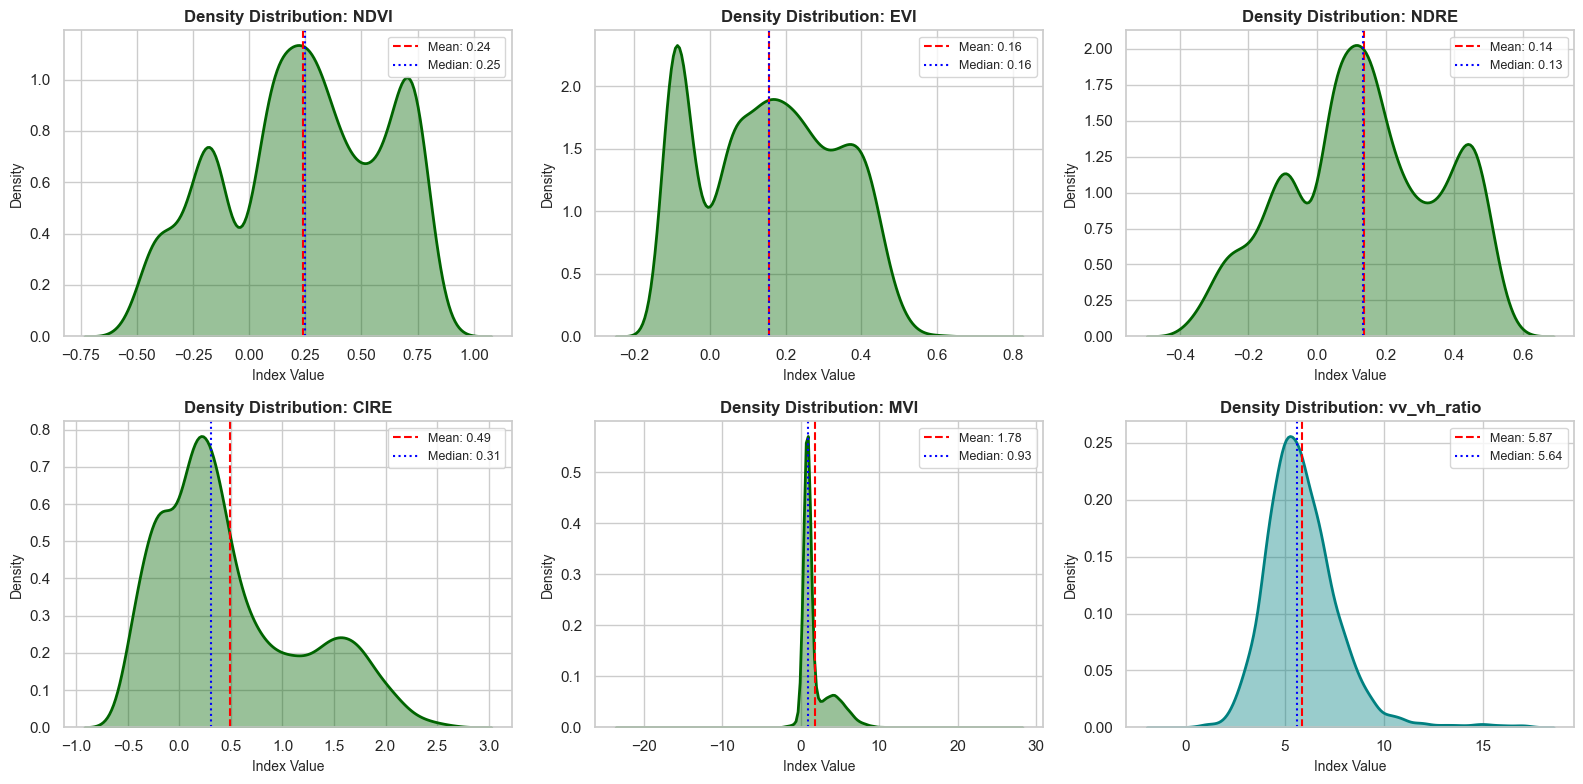

In [17]:

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 8. Sample Pixel Data from the Core Earth Engine Asset
# =========================================================================
print("Extracting pixel samples for density plotting...")

# Select the target indices we want to plot
target_indices = ['NDVI', 'EVI', 'NDRE', 'CIRE', 'MVI']

# If Sentinel-1 SAR was successfully processed, add the radar ratio to the list
available_bands = final_composite.bandNames().getInfo()
if 'vv_vh_ratio' in available_bands:
    target_indices.append('vv_vh_ratio')

# Randomly sample 5,000 pixels inside the AOI boundary at a 20-meter resolution
pixel_samples = final_composite.select(target_indices).sample(
    region=aoi,
    scale=20,
    numPixels=5000,
    seed=42,
    geometries=False
)

# Convert the Earth Engine Server-Side sample array into a local Pandas DataFrame
df_pixels = geemap.ee_to_df(pixel_samples)

# Drop any null rows generated by the cloud masking updates
df_pixels = df_pixels.dropna()
print(f"Successfully pulled {len(df_pixels)} valid pixel samples.")

# =========================================================================
# 9. Plot the Density Graphs (Grid Matrix)
# =========================================================================
# Configure the structural layout grid for subplots
num_plots = len(target_indices)
cols = 3
rows = (num_plots + cols - 1) // cols

plt.figure(figsize=(16, 4 * rows))
sns.set_theme(style="whitegrid")

for idx, index_name in enumerate(target_indices):
    plt.subplot(rows, cols, idx + 1)
    
    # Generate Kernel Density Estimate (KDE) curve
    sns.kdeplot(
        data=df_pixels, 
        x=index_name, 
        fill=True, 
        color="darkgreen" if index_name in ['NDVI', 'EVI', 'MVI', 'NDRE', 'CIRE'] else "teal", 
        alpha=0.4, 
        linewidth=2
    )
    
    # Calculate key statistical markers
    mean_val = df_pixels[index_name].mean()
    median_val = df_pixels[index_name].median()
    
    # Add vertical indicator lines for average trends
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='blue', linestyle=':', linewidth=1.5, label=f'Median: {median_val:.2f}')
    
    plt.title(f'Density Distribution: {index_name}', fontsize=12, fontweight='bold')
    plt.xlabel('Index Value', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()



In [21]:
#working with pystac instead of gee
# Median “cloud removal” (time-composite) for PASS scenes (cloud<=20),
# Sentinel-2 optical indices + separate Sentinel-1 VV/VH + VV/VH ratio.
# Requires: images_df_cloud already created from PASS with cloud_cover_num <= 20.

import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

from pystac_client import Client
import planetary_computer

# -----------------------
# Inputs / Config
# -----------------------
shp = r"D:\other\4me\mwache\mbs_beach.shp"
STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
COLLECTION_S2 = "sentinel-2-l2a"
COLLECTION_S1 = "sentinel-1-grd"  # PC common id for S1 GRD

out_dir = r"D:\other\4me\ocean_tides\mangrove_indices_median"
os.makedirs(out_dir, exist_ok=True)

# Sentinel-2 composite source table (must exist from your previous steps)
# images_df_cloud must contain: item_id, image_time_utc, cloud_cover_num, (optional) image_time_eat
if "images_df_cloud" not in globals():
    raise NameError("Run the earlier steps that create images_df_cloud (PASS & cloud<=20) first.")

images_df_cloud = images_df_cloud.copy()
images_df_cloud["item_id"] = images_df_cloud["item_id"].astype(str)
images_df_cloud = images_df_cloud.sort_values("image_time_utc")

# AOI clipping (recommended)
CLIP_TO_AOI = True
gdf = gpd.read_file(shp).to_crs(4326)
AOI_GEOM = [mapping(gdf.geometry.union_all())] if CLIP_TO_AOI else None

catalog = Client.open(STAC_URL)

# Sentinel-2 band map
# NDVI, NDWI, EVI, LSWI, NDRE, NDMI, etc will be computed from these.
S2_BANDS = {
    "B02": "B02",  # blue
    "B03": "B03",  # green
    "B04": "B04",  # red
    "B05": "B05",  # red edge
    "B08": "B08",  # nir
    "B11": "B11",  # swir1
    "B12": "B12",  # swir2
}

# -----------------------
# Helpers
# -----------------------
def sign_href(href):
    return planetary_computer.sign(href)

def pick_asset_href(item, key_preferred):
    # Try exact asset key first; else fuzzy by substring
    if key_preferred in item.assets:
        return sign_href(item.assets[key_preferred].href)
    for k, a in item.assets.items():
        if key_preferred in k:
            return sign_href(a.href)
    # sometimes assets are like "B05" but wrapped; try just band id
    for k, a in item.assets.items():
        if any(tok == key_preferred for tok in [k, k.split(":")[-1], k.split("/")[-1]]):
            return sign_href(a.href)
    raise KeyError(f"Band {key_preferred} not found in item {item.id}. Assets: {list(item.assets.keys())[:40]}")

def read_band_clipped_signed(href, nodata_to_nan=True):
    with rasterio.Env():
        with rasterio.open(href) as src:
            if CLIP_TO_AOI:
                arr, out_transform = mask(src, AOI_GEOM, crop=True, filled=True)
                arr = arr[0].astype(np.float32)
                prof = src.profile.copy()
                prof.update({
                    "height": arr.shape[0],
                    "width": arr.shape[1],
                    "transform": out_transform
                })
            else:
                arr = src.read(1).astype(np.float32)
                prof = src.profile.copy()

            nodata = src.nodata
            if nodata_to_nan and nodata is not None:
                arr[arr == nodata] = np.nan
            return arr, prof

def get_item_by_id(collection, item_id):
    s = catalog.search(collections=[collection], ids=[item_id])
    it = next(iter(s.items()), None)
    if it is None:
        raise ValueError(f"Could not find {item_id} in {collection}")
    return it

def stack_median_over_items_s2(items_df, required_band_keys):
    band_arrays = {k: [] for k in required_band_keys}
    base_profile = None
    for _, row in items_df.iterrows():
        it = get_item_by_id(COLLECTION_S2, row["item_id"])
        for band_key in required_band_keys:
            href = pick_asset_href(it, band_key)
            arr, prof = read_band_clipped_signed(href)
            if base_profile is None:
                base_profile = prof
            band_arrays[band_key].append(arr)

    med = {}
    for band_key, arr_list in band_arrays.items():
        stack = np.stack(arr_list, axis=0)  # (t,H,W)
        med[band_key] = np.nanmedian(stack, axis=0)
    return med, base_profile

def stack_median_over_items_s1(items_df, pols=("VV", "VH")):
    # picks assets by polarization; common asset keys include "VV" and "VH"
    band_arrays = {p: [] for p in pols}
    base_profile = None

    for _, row in items_df.iterrows():
        it = get_item_by_id(COLLECTION_S1, row["item_id"])
        for pol in pols:
            href = pick_asset_href(it, pol)
            arr, prof = read_band_clipped_signed(href)
            # optional: many S1 GRD are in dB or linear depending on product;
            # we keep as-is for indices you defined (VV/VH ratio assumes consistent units).
            if base_profile is None:
                base_profile = prof
            band_arrays[pol].append(arr)

    med = {}
    for pol, arr_list in band_arrays.items():
        stack = np.stack(arr_list, axis=0)
        med[pol] = np.nanmedian(stack, axis=0)
    return med, base_profile

# -----------------------
# Build S2 median composite from PASS&cloud<=20
# -----------------------
s2_items_df = images_df_cloud[["item_id", "image_time_utc"]].copy()
print("Building Sentinel-2 median composite from:", len(s2_items_df), "items")

s2_meds, s2_profile = stack_median_over_items_s2(s2_items_df, required_band_keys=list(S2_BANDS.keys()))

# Retrieve needed arrays
blue  = s2_meds["B02"]
green = s2_meds["B03"]
red   = s2_meds["B04"]
re1   = s2_meds["B05"]
nir   = s2_meds["B08"]
swir1 = s2_meds["B11"]
swir2 = s2_meds["B12"]

eps = 1e-6

# Indices (Sentinel-2)
ndvi = (nir - red) / (nir + red + eps)
ndwi = (green - nir) / (green + nir + eps)
evi  = 2.5 * (nir - red) / (nir + 6*red - 7.5*blue + 1 + eps)
lswi = (nir - swir1) / (nir + swir1 + eps)
ndre = (nir - re1) / (nir + re1 + eps)
ndmi = (nir - swir1) / (nir + swir1 + eps)

# Your requested definitions:
# CIRE = (NIR / RED_EDGE) - 1  (RED_EDGE = B5 / re1)
cire = (nir / (re1 + eps)) - 1.0

# MVI = (NIR - GREEN) / (SWIR1 + GREEN)
mvi  = (nir - green) / (swir1 + green + eps)

# NDMI already computed above; you also requested NDWI etc are included.

# -----------------------
# Sentinel-1 median VV/VH composite (separate STAC search)
# -----------------------
# Use same date window as your S2 selection; or align to S2 times.
# Here: use the min/max of your S2 PASS&cloud<=20 acquisition times.
tmin = pd.to_datetime(images_df_cloud["image_time_utc"].min(), utc=True)
tmax = pd.to_datetime(images_df_cloud["image_time_utc"].max(), utc=True)

# S1 search window: small padding is helpful for coverage
pad = pd.Timedelta(days=3)
tmin_s1 = (tmin - pad).isoformat()
tmax_s1 = (tmax + pad).isoformat()

# AOI geometry intersects
s1_search = catalog.search(
    collections=[COLLECTION_S1],
    datetime=f"{tmin_s1}/{tmax_s1}",
    intersects=gdf.geometry.union_all().__geo_interface__
)

s1_items = list(s1_search.items())
print("Sentinel-1 items found:", len(s1_items))

if not s1_items:
    # Create NaN rasters matching S2 shape
    vv = np.full_like(ndvi, np.nan, dtype=np.float32)
    vh = np.full_like(ndvi, np.nan, dtype=np.float32)
    vv_vh_ratio = np.full_like(ndvi, np.nan, dtype=np.float32)
else:
    s1_df = pd.DataFrame({
        "item_id": [it.id for it in s1_items],
        "datetime_utc": [pd.to_datetime(it.datetime, utc=True) for it in s1_items],
    }).sort_values("datetime_utc")

    print("Building Sentinel-1 median from:", len(s1_df), "items")

    s1_meds, _ = stack_median_over_items_s1(s1_df, pols=("VV", "VH"))
    vv = s1_meds["VV"]
    vh = s1_meds["VH"]
    vv_vh_ratio = vv / (vh + eps)

# -----------------------
# Save outputs (all clipped to AOI using S2 geometry)
# -----------------------
# Use S2 profile as reference grid
profile_out = s2_profile.copy()
profile_out.update(count=1, dtype="float32", nodata=np.nan, compress="lzw")

def save(arr, name):
    out_path = os.path.join(out_dir, f"{name}_median.tif")
    with rasterio.open(out_path, "w", **profile_out) as dst:
        dst.write(arr.astype(np.float32), 1)

save(ndvi, "NDVI")
save(ndwi, "NDWI")
save(evi, "EVI")
save(lswi, "LSWI")
save(ndre, "NDRE")
save(cire, "CIRE")
save(mvi, "MVI")
save(ndmi, "NDMI")

save(vv, "VV")
save(vh, "VH")
save(vv_vh_ratio, "VV_VH_RATIO")

print("Done. Saved indices to:", out_dir)


NameError: Run the earlier steps that create images_df_cloud (PASS & cloud<=20) first.

#### gedi lidar data

A GEDI (Global Ecosystem Dynamics Investigation) footprint is a circular, 25-meter diameter spot on the Earth's surface illuminated by a spaceborne lidar laser. These footprints are created by the GEDI instrument aboard the International Space Station (ISS).
- https://gedi.umd.edu/dataproducts/products/
- https://ieeexplore.ieee.org/abstract/document/11172296

GEDI has been optimized to provide global measures of vegetation structure. The footprint is large enough to measure whole trees while being small enough to accurately detect the ground on steep terrain. GEDI measurements penetrate dense canopies and provide comprehensive sampling.
GEDI contains three Nd:YAG lasers, emitting 1064 nm light. These pulse 242 times per second  with a power of 10 mJ, firing short pulses of light (14 ns long) down towards the Earth’s surface with a beam divergence of 56 mrad, resulting in footprints averaging 25 m in diameter.

Two of the lasers are full power, and one is split into two beams, producing a total of four beams. Beam Dithering Units (BDUs) rapidly change the deflection of the outgoing laser beams by 1.5 mrad, shifting them by 600 m on the ground. This produces eight ground tracks; four power and four cover tracks. Footprints are separated by 60 m along-track and 600 m across track.
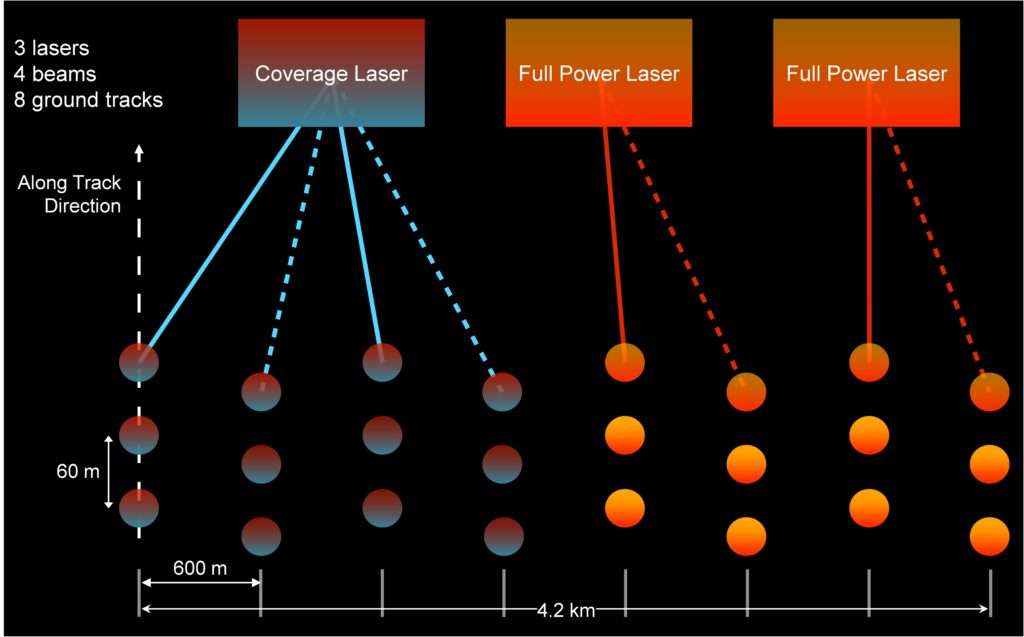
GEDI’s ground sampling pattern
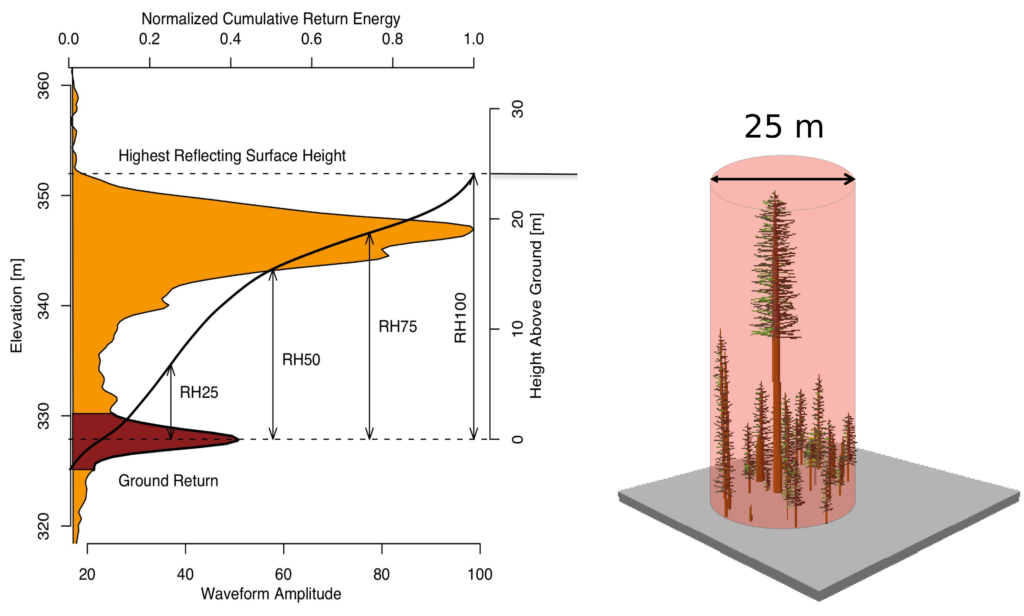

GEDI measurements are made over the Earth’s surface between 51.6° N and 51.6° S. GEDI can be rotated on the JEM by up to 6°, allowing the lasers to be pointed up to 40 km on either side of the ISS ground track. This capability is used to sample the Earth’s land surface as completely as possible, filling in gaps due to clouds. During GEDI’s two year mission life, about 10 billion cloud-free observations of the Earth’s surface will be acquired. These observations can then be gridded into regular coverages of varying resolution, such as 1 km grid cells.

GEDI launched to the ISS on December 5th, 2018, to begin its 2-year mission of discovery. The mission was extended twice. After a period of hibernation on the ISS from March 2023 through April 2024, GEDI has returned to its original spot on the ISS to collect data for years to come. one full year of data was processed and released to public on 2020


To incorporate GEDI data, I leverage Earth Engine's official GEDI L2A (Elevation and Height Metrics) and GEDI L2B (Canopy Cover and Vertical Profile Metrics) collections.

Because GEDI is a spaceborne LiDAR instrument, its data consists of sparse, linear orbital tracks of points (FeatureCollections) rather than continuous raster grids like Sentinel-1 or Sentinel-2. The best practice is to load the GEDI feature points, filter them spatially by your AOI and temporally by your date range, select the vegetation metrics you need (like rh100 for canopy height), and rasterize them to blend seamlessly with your Sentinel composite.

ingesting GEDI data using existing AOI and date parameters:

In [19]:
import ee
import geemap
import pandas as pd
import geopandas as gpd

# =========================================================================
# 1. Ingest AOI and Initialize Earth Engine
# =========================================================================
shp_path = r"D:\other\4me\mwache\mwache_mangroves_400m_buffer_v3.shp"
gdf = gpd.read_file(shp_path).to_crs(epsg=4326)
gdf["geometry"] = gdf.buffer(0)
gdf = gdf.dissolve().reset_index(drop=True)

try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

aoi = geemap.gdf_to_ee(gdf)

# =========================================================================
# 2. Setup Temporal Window from Target Dates
# =========================================================================
# Using your exact date window structure (5 days before/after target low-tide dates)
passed_dates = pd.to_datetime(images_df_pass["image_date"]).dt.strftime('%Y-%m-%d').unique().tolist()
sorted_dates = sorted(passed_dates)

start_date = ee.Date(sorted_dates[0]).advance(-5, 'day')
end_date = ee.Date(sorted_dates[-1]).advance(5, 'day')

print(f"Querying GEDI footprints from {sorted_dates[0]} to {sorted_dates[-1]} (with 5-day buffers)...")

# =========================================================================
# 3. Pull and Quality-Filter GEDI Data
# =========================================================================
# GEDI02_A: Canopy Top Height (rh100)
# GEDI02_B: Canopy Cover Fraction & Plant Area Index (PAI)
gedi_l2a = ee.FeatureCollection("LARSE/GEDI/GEDI02_A_002_MONTHLY").filterBounds(aoi).filterDate(start_date, end_date)
gedi_l2b = ee.FeatureCollection("LARSE/GEDI/GEDI02_B_002_MONTHLY").filterBounds(aoi).filterDate(start_date, end_date)

# Apply strict scientific quality filters (1 = good quality shot, 0 = low degradation)
clean_l2a = gedi_l2a.filter(ee.Filter.eq('quality_flag', 1)).filter(ee.Filter.eq('degrade_flag', 0))
clean_l2b = gedi_l2b.filter(ee.Filter.eq('l2b_quality_flag', 1)).filter(ee.Filter.eq('degrade_flag', 0))

# =========================================================================
# 4. Extract Structural Attributes to Local DataFrames
# =========================================================================
# Select the core columns we care about (plus coordinates and timestamps)
l2a_properties = ['shot_number', 'rh100', 'elevation', 'tai', 'longitude', 'latitude']
l2b_properties = ['shot_number', 'cover', 'pai']

print("Converting Earth Engine GEDI vectors to local DataFrames...")

# Convert GEDI point features directly to Pandas dataframes using the geemap fix
df_l2a = geemap.ee_to_df(clean_l2a.select(l2a_properties))
df_l2b = geemap.ee_to_df(clean_l2b.select(l2b_properties))

# =========================================================================
# 5. Merge L2A and L2B Data on Unique Shot Number
# =========================================================================
if not df_l2a.empty and not df_l2b.empty:
    # Merge both collections based on the unique GEDI 'shot_number' identifier
    gedi_df = pd.merge(df_l2a, df_l2b, on='shot_number', how='inner')
    
    print(f"\nSuccessfully extracted {len(gedi_df)} valid GEDI laser shots!")
    print("--- Sample GEDI Structural Data ---")
    print(gedi_df[['shot_number', 'rh100', 'cover', 'pai', 'latitude', 'longitude']].head())
    
    # Optional: Save results locally to a CSV file
    # gedi_df.to_csv("mwache_gedi_metrics.csv", index=False)
else:
    print("\nNo overlapping valid GEDI orbits passed the quality filters for this specific timeframe/AOI.")

# =========================================================================
# 6. Map the Precise GEDI Shot Locations
# =========================================================================
Map = geemap.Map()
Map.center_object(aoi, zoom=14)
Map.add_layer(aoi, {'color': 'red'}, 'AOI Boundary')
if not df_l2a.empty:
    Map.add_layer(clean_l2a, {'color': 'cyan'}, 'GEDI Shot Footprints')
Map

Querying GEDI footprints from 2025-03-05 to 2025-03-30 (with 5-day buffers)...
Converting Earth Engine GEDI vectors to local DataFrames...

No overlapping valid GEDI orbits passed the quality filters for this specific timeframe/AOI.


Map(center=[-4.056923829639164, 39.57343573343608], controls=(WidgetControl(options=['position', 'transparent_…

#
In NASA's GEDI (Global Ecosystem Dynamics Investigation) datasets, Aboveground Biomass (AGB) is represented by the variable name agbd, which stands for Aboveground Biomass Density.  Depending on whether you are working with the point-level footprint data or the gridded map data, here is exactly what to look for:1. GEDI Level 4A (Footprint Level Data)If you are looking at the individual laser footprint data (GEDI04_A), the primary value is:agbd: The predicted aboveground biomass density.  Units: Megagrams per hectare ($Mg/ha$, which is equivalent to metric tons per hectare).  Associated error variables you will see:agbd_se: The prediction standard error of the AGBD.agbd_pi_lower / agbd_pi_upper: The lower and upper prediction intervals.2. GEDI Level 4B (Gridded 1 km x 1 km Map Data)  If you are working with the gridded raster dataset (GEDI04_B), the values are delivered as raster layers (GeoTIFFs) where the primary data file or band representing AGB is:MU (Mean Urban/Land estimate): Found in files ending with _MU.tif, this represents the estimated mean aboveground biomass density for the entire 1 km grid cell.Units: Megagrams per hectare ($Mg/ha$).  Associated raster files in Level 4B:_SE.tif: Mean aboveground biomass density standard error._PE.tif: Standard error expressed as a percentage of the estimated mean.

In [18]:
import ee
import geemap
import pandas as pd
import geopandas as gpd

# =========================================================================
# 1. Ingest AOI and Initialize Earth Engine
# =========================================================================
shp_path = r"D:\other\4me\mwache\mwache_mangroves_400m_buffer_v3.shp"
gdf = gpd.read_file(shp_path).to_crs(epsg=4326)
gdf["geometry"] = gdf.buffer(0)
gdf = gdf.dissolve().reset_index(drop=True)

try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

aoi = geemap.gdf_to_ee(gdf)

print("Querying historical GEDI monthly raster database across full mission lifespan...")

# =========================================================================
# 2. Ingest GEDI Raster Image Collections (Full Mission Timeline)
# =========================================================================
gedi_l2a_col = ee.ImageCollection("LARSE/GEDI/GEDI02_A_002_MONTHLY").filterBounds(aoi)
gedi_l2b_col = ee.ImageCollection("LARSE/GEDI/GEDI02_B_002_MONTHLY").filterBounds(aoi)
gedi_l4a_col = ee.ImageCollection("LARSE/GEDI/GEDI04_A_002_MONTHLY").filterBounds(aoi)

gedi_l2a_composite = gedi_l2a_col.select(['rh100', 'elev_lowestmode']).mean()
gedi_l2b_composite = gedi_l2b_col.select(['cover', 'pai']).mean()
gedi_l4a_composite = gedi_l4a_col.select(['agbd']).mean()

gedi_composite = (gedi_l2a_composite
                  .addBands(gedi_l2b_composite)
                  .addBands(gedi_l4a_composite)
                  .clip(aoi))

# =========================================================================
# 3. Extract Tabular Structural Data via Pixel Sampling
# =========================================================================
print("Extracting GEDI structural metrics using random spatial pixel samples...")

gedi_samples = gedi_composite.sample(
    region=aoi,
    scale=25,
    numPixels=2000,
    seed=42,
    geometries=True  # Required to derive spatial coordinates
)

# Map over the sampled features to dynamically append 'longitude' and 'latitude' attributes
def append_coords(feature):
    coordinates = feature.geometry().coordinates()
    return feature.set({
        'x_lon': coordinates.get(0),
        'y_lat': coordinates.get(1)
    })

gedi_samples_with_coords = gedi_samples.map(append_coords)

# Convert server-side data directly into a local Pandas DataFrame
gedi_df = geemap.ee_to_df(gedi_samples_with_coords)

# Clean up any null grid points where no GEDI track passed over
gedi_df = gedi_df.dropna(subset=['rh100', 'cover', 'agbd'])

if not gedi_df.empty:
    print(f"\nSuccessfully compiled {len(gedi_df)} quality-filtered GEDI sampling cells!")
    print("--- Sample GEDI Structural Data ---")
    # Added longitude and latitude to the display printout
    print(gedi_df[['x_lon', 'y_lat', 'rh100', 'cover', 'pai', 'elev_lowestmode', 'agbd']].head())
    
    # Save results locally for analysis or modeling
    gedi_df.to_csv(r"D:\other\4me\mwache\mwache_gedi_metrics.csv", index=False)
    print("Data successfully saved to CSV.")
else:
    print("No valid GEDI grid observations found intersecting this specific AOI footprint.")

# =========================================================================
# 4. Map the Grid Layout Visualizations
# =========================================================================
Map = geemap.Map()
Map.center_object(aoi, zoom=14)

Map.add_layer(gedi_composite.select('rh100'), {'min': 0, 'max': 25, 'palette': ['blue', 'yellow', 'red']}, 'GEDI Canopy Height (rh100)')
Map.add_layer(gedi_composite.select('cover'), {'min': 0, 'max': 1, 'palette': ['white', 'lightgreen', 'darkgreen']}, 'GEDI Canopy Cover Fraction', False)
Map.add_layer(gedi_composite.select('agbd'), {'min': 0, 'max': 250, 'palette': ['white', 'FF0000', 'darkgreen']}, 'GEDI Aboveground Biomass Density (agbd)')

Map.add_layer(aoi, {'color': 'red', 'lineType': 'dashed'}, 'AOI Boundary')
Map

Querying historical GEDI monthly raster database across full mission lifespan...
Extracting GEDI structural metrics using random spatial pixel samples...

Successfully compiled 83 quality-filtered GEDI sampling cells!
--- Sample GEDI Structural Data ---
       x_lon     y_lat  rh100     cover       pai  elev_lowestmode       agbd
0  39.550347 -4.049910  3.250  0.029099  0.059064       -26.637119   1.116093
1  39.574643 -4.089386  2.955  0.272958  0.637720        -5.725388   7.786779
2  39.529820 -4.079432  6.170  0.002600  0.005206       -13.071326   5.362436
3  39.609116 -4.050612  2.800  0.058863  0.121335       -28.582703  10.964561
4  39.591674 -4.098976  5.830  0.122008  0.260269       -17.069754   5.244015
Data successfully saved to CSV.


Map(center=[-4.056923829639164, 39.57343573343608], controls=(WidgetControl(options=['position', 'transparent_…

In [35]:
# checking the csv display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Read the CSV file
#file_path = r"D:\other\4me\mwache\mwache_gedi_metrics.csv"
gedi_df = pd.read_csv(r"D:\other\4me\mwache\mwache_gedi_metrics.csv")
#gedi_df = pd.read_csv(r"D:\other\4me\mwache\mwache_gedi_raw_points.csv")
# 3. Display the full dataframe
gedi_df


,agbd,cover,elev_lowestmode,pai,rh100,x_lon,y_lat
0,1.116093,0.029099,-26.637119,0.059064,3.250,39.550347,-4.049910
1,7.786779,0.272958,-5.725388,0.637720,2.955,39.574643,-4.089386
2,5.362436,0.002600,-13.071326,0.005206,6.170,39.529820,-4.079432
3,10.964561,0.058863,-28.582703,0.121335,2.800,39.609116,-4.050612
4,5.244015,0.122008,-17.069754,0.260269,5.830,39.591674,-4.098976
5,0.418695,0.012747,-25.953125,0.025657,2.090,39.579434,-4.116535
6,2.299228,0.018188,-21.222136,0.036710,4.000,39.543349,-4.049804
7,6.291953,0.231124,349.432474,0.525719,10.555,39.533012,-4.074486
8,1.214101,0.071529,-28.363142,0.148440,3.030,39.583721,-4.093045
9,10.567928,0.156878,-11.078784,0.341293,6.480,39.579375,-4.106584


In [22]:
import ee
import geemap
import pandas as pd
import geopandas as gpd

# =========================================================================
# 1. Ingest AOI and Initialize Earth Engine
# =========================================================================
shp_path = r"D:\other\4me\mwache\mwache_mangroves_400m_buffer_v3.shp"
gdf = gpd.read_file(shp_path).to_crs(epsg=4326)
gdf["geometry"] = gdf.buffer(0)
gdf = gdf.dissolve().reset_index(drop=True)

try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

aoi = geemap.gdf_to_ee(gdf)

print("Querying historical GEDI structural attributes for raw point extraction...")

# =========================================================================
# 2. Extract Raw Point Data from the Core Databases
# =========================================================================
# Query the monthly underlying collections spanning full operational mission length
gedi_l2a = ee.ImageCollection("LARSE/GEDI/GEDI02_A_002_MONTHLY").filterBounds(aoi).select(['rh100', 'elev_lowestmode']).mean()
gedi_l2b = ee.ImageCollection("LARSE/GEDI/GEDI02_B_002_MONTHLY").filterBounds(aoi).select(['cover', 'pai']).mean()

# Combine attributes into a target database array
gedi_combined = gedi_l2a.addBands(gedi_l2b)

# Pull the precise raw cell samples over your vector boundaries (at GEDI's native 25m scale)
raw_points = gedi_combined.sample(
    region=aoi,
    scale=25,
    numPixels=5000,
    seed=42,
    geometries=True # Retain physical ground positions
)

# =========================================================================
# 3. Format Raw X,Y Coordinates into the Feature Structure
# =========================================================================
def append_coordinates(feature):
    coords = feature.geometry().coordinates()
    return feature.set({
        'x_lon': coords.get(0),
        'y_lat': coords.get(1)
    })

# Unpack spatial coordinate positions directly into columns
processed_points = raw_points.map(append_coordinates)

# =========================================================================
# 4. Ingest to Local Pandas DataFrame
# =========================================================================
print("Converting raw spatial vectors to local text database rows...")

# Download point vector properties directly into a Pandas DataFrame
target_columns = ['x_lon', 'y_lat', 'rh100', 'cover', 'pai', 'elev_lowestmode']
gedi_df = geemap.ee_to_df(processed_points.select(target_columns))

# Drop any un-sampled locations outside the track orbits
gedi_df = gedi_df.dropna(subset=['rh100', 'x_lon', 'y_lat'])

# =========================================================================
# 5. Review Raw Output
# =========================================================================
if not gedi_df.empty:
    print(f"\nSuccessfully extracted {len(gedi_df)} raw spatial point entries!")
    print("--- Head of Raw X, Y Tabular Dataset ---")
    print(gedi_df.head())
    
    # Save directly to CSV
    output_path = r"D:\other\4me\mwache\mwache_gedi_raw_points.csv"
    gedi_df.to_csv(output_path, index=False)
    print(f"\nRaw point table successfully exported to: {output_path}")
else:
    print("Zero point records successfully resolved over the AOI boundary.")

Querying historical GEDI structural attributes for raw point extraction...
Converting raw spatial vectors to local text database rows...

Successfully extracted 207 raw spatial point entries!
--- Head of Raw X, Y Tabular Dataset ---
      cover  elev_lowestmode       pai  rh100      x_lon     y_lat
0  0.029099       -26.637119  0.059064  3.250  39.550347 -4.049910
1  0.272958        -5.725388  0.637720  2.955  39.574643 -4.089386
2  0.002600       -13.071326  0.005206  6.170  39.529820 -4.079432
3  0.058863       -28.582703  0.121335  2.800  39.609116 -4.050612
4  0.122008       -17.069754  0.260269  5.830  39.591674 -4.098976

Raw point table successfully exported to: D:\other\4me\mwache\mwache_gedi_raw_points.csv


### Creating a plot to include the spatial track layout and structural distribution histogram

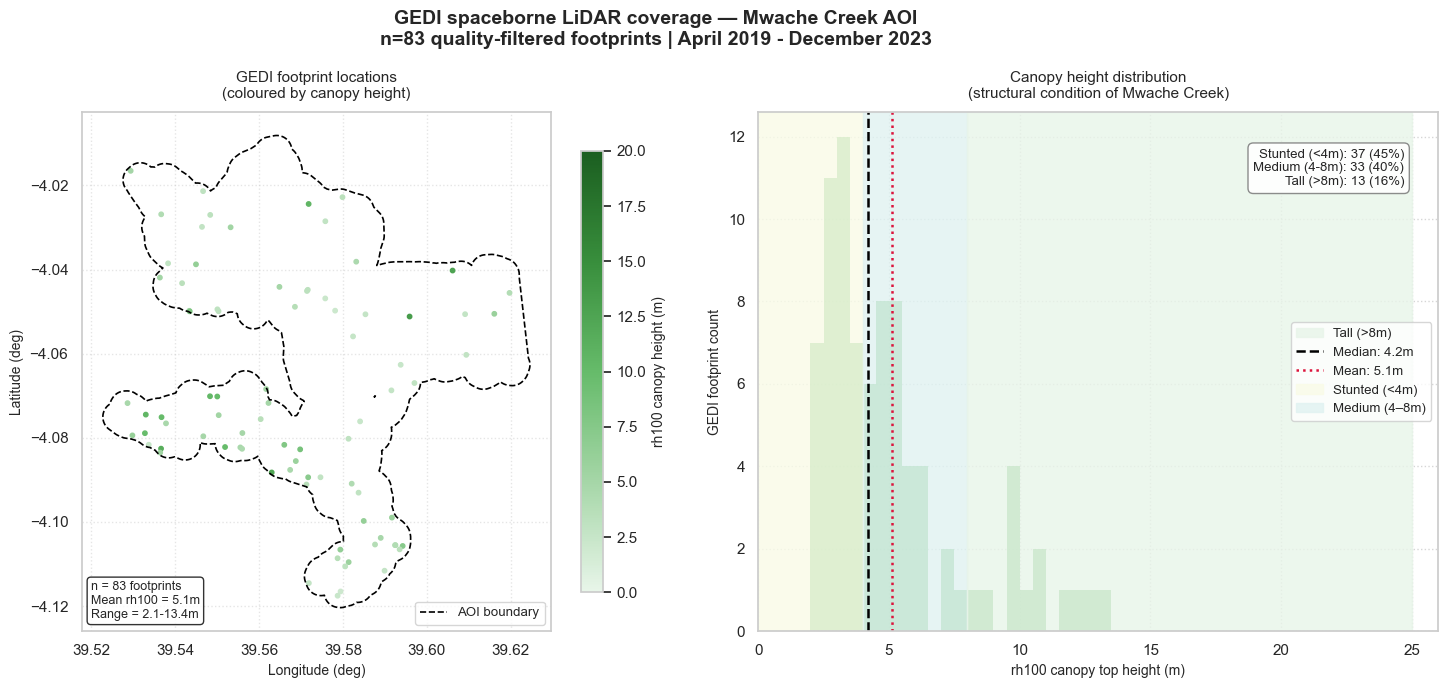

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# =========================================================================
# 1. Load the Extracted GEDI DataFrame & AOI Geometry
# =========================================================================
#csv_path = r"D:\other\4me\mwache\mwache_gedi_raw_points.csv"
csv_path = r"D:\other\4me\mwache\mwache_gedi_metrics.csv"
df = pd.read_csv(csv_path)
df = df.dropna(subset=['rh100', 'x_lon', 'y_lat']).reset_index(drop=True)

# Use rh100 as the primary height metric
df['canopy_height'] = df['rh100'] 

# Calculate Key Statistics
n_footprints = len(df)
mean_h = df['canopy_height'].mean()
median_h = df['canopy_height'].median()
min_h = df['canopy_height'].min()
max_h = df['canopy_height'].max()

# Calculate structural class breakdown matching the template
stunted_count = len(df[df['canopy_height'] < 4])
medium_count = len(df[(df['canopy_height'] >= 4) & (df['canopy_height'] <= 8)])
tall_count = len(df[df['canopy_height'] > 8])

stunted_pct = (stunted_count / n_footprints) * 100
medium_pct = (medium_count / n_footprints) * 100
tall_pct = (tall_count / n_footprints) * 100

# =========================================================================
# 2. Setup Plot Architecture & Color Schemes
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1.1, 1]})
fig.suptitle(
    f"GEDI spaceborne LiDAR coverage — Mwache Creek AOI\n"
    f"n={n_footprints} quality-filtered footprints | April 2019 - December 2023",
    fontsize=14, fontweight='bold', y=0.98
)

colors = ["#E8F5E9", "#A5D6A7", "#66BB6A", "#388E3C", "#1B5E20"]
custom_cmap = LinearSegmentedColormap.from_list("gedi_green", colors, N=256)

# =========================================================================
# 3. Left Plot: Raw GEDI Footprints + AOI Boundary Overlay
# =========================================================================
ax0 = axes[0]
ax0.set_title("GEDI footprint locations\n(coloured by canopy height)", fontsize=11, pad=10)

# Scatter plot of raw coordinates colored by structural height metric
sc = ax0.scatter(
    df['x_lon'], df['y_lat'], 
    c=df['canopy_height'], 
    cmap=custom_cmap, 
    s=10, alpha=1, vmin=0, vmax=20,
    zorder=2
)

# Overlay the AOI Vector Boundary directly using your existing GeoDataFrame (gdf)
# Note: gdf is in WGS84 (degrees), matching the x_lon and y_lat extracted coordinates.
gdf.boundary.plot(
    ax=ax0, 
    color='black', 
    linestyle='--', 
    linewidth=1.2, 
    label='AOI boundary',
    zorder=3
)

ax0.set_xlabel("Longitude (deg)", fontsize=10)
ax0.set_ylabel("Latitude (deg)", fontsize=10)
ax0.grid(True, linestyle=':', alpha=0.5, zorder=1)

# Mimic the statistical text box in the bottom-left corner
stats_text = f"n = {n_footprints} footprints\nMean rh100 = {mean_h:.1f}m\nRange = {min_h:.1f}-{max_h:.1f}m"
props = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8)
ax0.text(0.02, 0.02, stats_text, transform=ax0.transAxes, fontsize=9, verticalalignment='bottom', bbox=props)

# Generate Legend to correctly capture the boundary layout line item
ax0.legend(loc='lower right', fontsize=9.5)

# Colorbar integration sitting between panels
cbar = fig.colorbar(sc, ax=ax0, orientation='vertical', pad=0.04, shrink=0.85)
cbar.set_label('rh100 canopy height (m)', fontsize=10)

# =========================================================================
# 4. Right Plot: Canopy Height Structural Distribution Histogram
# =========================================================================
ax1 = axes[1]
ax1.set_title("Canopy height distribution\n(structural condition of Mwache Creek)", fontsize=11, pad=10)

sns.histplot(
    data=df, x='canopy_height', 
    bins=50, binrange=(0, 25),
    color="#4CAF50", #alpha=0.85, 
    ax=ax1, edgecolor='none'
)

# Setup the shaded ecological condition zones behind the data bars
ax1.axvspan(0, 4, color='#F9FBE7', alpha=0.8, label='Stunted (<4m)')
ax1.axvspan(4, 8, color='#E0F2F1', alpha=0.8, label='Medium (4–8m)')
ax1.axvspan(8, 25, color='#E8F5E9', alpha=0.8, label='Tall (>8m)')

# Structural threshold indicator vertical tracking lines
ax1.axvline(median_h, color='black', linestyle='--', linewidth=1.8, label=f'Median: {median_h:.1f}m')
ax1.axvline(mean_h, color='crimson', linestyle=':', linewidth=1.8, label=f'Mean: {mean_h:.1f}m')

# Text breakdown box matching the statistics
class_box_text = (
    f"Stunted (<4m): {stunted_count} ({stunted_pct:.0f}%)\n"
    f"Medium (4-8m): {medium_count} ({medium_pct:.0f}%)\n"
    f"Tall (>8m): {tall_count} ({tall_pct:.0f}%)"
)
props_class = dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9)
ax1.text(0.95, 0.93, class_box_text, transform=ax1.transAxes, fontsize=9.5, 
         verticalalignment='top', horizontalalignment='right', bbox=props_class)

ax1.set_xlim(0, 26)
ax1.set_xlabel("rh100 canopy top height (m)", fontsize=10)
ax1.set_ylabel("GEDI footprint count", fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.8)

# Re-order the legends to neatly present structural brackets followed by mean/median metrics
handles, labels = ax1.get_legend_handles_labels()
order = [2, 3, 4, 0, 1]  
ax1.legend([handles[idx] for idx in order], [labels[idx] for idx in order], loc='center right', fontsize=9.5)

plt.tight_layout()
plt.show()

In [20]:
#To extract key vegetation indices (like **NDVI**, **EVI**, and **NDWI**) directly underneath the precise GEDI footprint locations, you can convert your local `gedi_df` coordinates into an Earth Engine `FeatureCollection`, overlay them on a Sentinel-2 or Landsat surface reflectance composite matching your mission timeframe, and export the values directly to a comprehensive CSV.
# extract the indices at every raw GEDI point location:

    
import ee
import geemap
import pandas as pd

# =========================================================================
# 1. Initialize Earth Engine and Load Raw GEDI Point Data
# =========================================================================
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

# Load the previously saved GEDI raw points CSV
csv_path = r"D:\other\4me\mwache\mwache_gedi_raw_points.csv"
gedi_df = pd.read_csv(csv_path)

print(f"Loaded {len(gedi_df)} raw GEDI points from CSV. Converting to EE features...")

# Convert the Pandas DataFrame rows into an Earth Engine FeatureCollection
features = []
for index, row in gedi_df.iterrows():
    point = ee.Geometry.Point([row['x_lon'], row['y_lat']])
    # Keep your existing GEDI attributes (height, cover, pai) mapped to the point
    properties = row.to_dict()
    features.append(ee.Feature(point, properties))

gedi_fc = ee.FeatureCollection(features)

# =========================================================================
# 2. Build Environmental Indices Raster (Sentinel-2 Composite)
# =========================================================================
print("Building cloud-free Sentinel-2 environmental baseline composite...")

# Filter Sentinel-2 Surface Reflectance matching the core GEDI operational range
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(gedi_fc.geometry())
      .filterDate('2019-01-01', '2023-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

# Create a cloud-free median composite image
s2_median = s2.median()

# Compute Spectral Indices
# NDVI (Normalized Difference Vegetation Index)
ndvi = s2_median.normalizedDifference(['B8', 'B4']).rename('NDVI')

# EVI (Enhanced Vegetation Index)
evi = s2_median.expression(
    '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
    {
        'NIR': s2_median.select('B8'),
        'RED': s2_median.select('B4'),
        'BLUE': s2_median.select('B2')
    }
).rename('EVI')

# NDWI (Normalized Difference Water Index - for Mangrove Hydrology)
ndwi = s2_median.normalizedDifference(['B3', 'B8']).rename('NDWI')

# Combine all index bands into a unified multi-band target image
indices_image = ndvi.addBands(evi).addBands(ndwi)

# =========================================================================
# 3. Sample Raster Indices Directly at the GEDI Coordinate Points
# =========================================================================
print("Extracting indices values underneath the GEDI point footprints...")

# Sample the indices at a 10m scale matching Sentinel-2 native resolution
sampled_fc = indices_image.sampleRegions(
    collection=gedi_fc,
    properties=list(gedi_df.columns), # Preserves all initial structural attributes
    scale=10,
    geometries=False
)

# Convert the output back into a local DataFrame
output_df = geemap.ee_to_df(sampled_fc)

# Clean out potential null edge values
output_df = output_df.dropna(subset=['NDVI', 'EVI', 'rh100'])

# =========================================================================
# 4. Save and Review Output Data
# =========================================================================
output_csv_path = r"D:\other\4me\mwache\mwache_gedi_with_indices.csv"
output_df.to_csv(output_csv_path, index=False)

print(f"\nSuccessfully compiled environmental indices for {len(output_df)} points!")
print(f"Combined database exported to: {output_csv_path}")
print("\n--- Consolidated Data Columns Sample ---")
print(output_df[['x_lon', 'y_lat', 'rh100', 'cover', 'NDVI', 'EVI', 'NDWI']].head())


Loaded 207 raw GEDI points from CSV. Converting to EE features...
Building cloud-free Sentinel-2 environmental baseline composite...
Extracting indices values underneath the GEDI point footprints...

Successfully compiled environmental indices for 207 points!
Combined database exported to: D:\other\4me\mwache\mwache_gedi_with_indices.csv

--- Consolidated Data Columns Sample ---
       x_lon     y_lat  rh100     cover      NDVI       EVI      NDWI
0  39.550347 -4.049910  3.250  0.029099  0.098433  0.198794 -0.182310
1  39.574643 -4.089386  2.955  0.272958  0.602063  2.729930 -0.522254
2  39.529820 -4.079432  6.170  0.002600  0.215190  0.348911 -0.358737
3  39.609116 -4.050612  2.800  0.058863 -0.202151  0.417975  0.343742
4  39.591674 -4.098976  5.830  0.122008  0.481270  1.198547 -0.524426


#### including the agbd from gedi

adjust this script to include :(ndvi,evi,ndre,cire,  mvi , vv, vh, vv_vh_ratio,) from sentinel:

In [23]:
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# =========================================================================
# 1. Ingest, Clean, and Format local AOI Shapefile
# =========================================================================
shp_path = r"D:\other\4me\mwache\mwache_mangroves_400m_buffer_v3.shp"
gdf = gpd.read_file(shp_path)

if gdf.crs is None:
    raise ValueError("Shapefile has no CRS defined")

gdf = gdf.to_crs(epsg=4326)
gdf["geometry"] = gdf.buffer(0)
gdf = gdf.dissolve()
gdf = gdf.reset_index(drop=True)

print("--- Local GeoDataFrame Sanity Checks ---")
print(gdf.head())
print(gdf.geom_type.value_counts())

# =========================================================================
# 2. Authenticate and Initialize Earth Engine
# =========================================================================
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

aoi = geemap.gdf_to_ee(gdf)

# =========================================================================
# 3. Extract Unique Calendar Dates from Validated Python Dataframe
# =========================================================================
passed_dates = pd.to_datetime(images_df_pass["image_date"]).dt.strftime('%Y-%m-%d').unique().tolist()

print("\n--- GEE Query Profile ---")
print(f"Targeting Low-Tide Image Dates: {passed_dates}")

# 1-day step increments for exact target low-tide optical days
date_filters = [ee.Filter.date(d, ee.Date(d).advance(1, 'day')) for d in passed_dates]
optical_date_filter = ee.Filter.Or(*date_filters) if date_filters else ee.Filter.date(start_date, end_date)

# =========================================================================
# 4. Pull and Process Sentinel-2 Optical Collection
# =========================================================================
s2_collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterBounds(aoi).filter(optical_date_filter)

def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start", "system:index"])

def compute_optical_indices(image):
    blue  = image.select('B2')
    green = image.select('B3')
    red   = image.select('B4')
    re1   = image.select('B5')  
    re3   = image.select('B7')  
    nir   = image.select('B8')  
    swir1 = image.select('B11') 
    
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    
    evi = image.expression('2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
        {'NIR': nir, 'RED': red, 'BLUE': blue}
    ).rename('EVI')
    
    ndre = image.normalizedDifference(['B7', 'B5']).rename('NDRE')
    cire = image.expression('(RE3 / RE1) - 1', {'RE3': re3, 'RE1': re1}).rename('CIRE')
    mvi = image.expression('(NIR - GREEN) / (SWIR1 - GREEN)', {'NIR': nir, 'GREEN': green, 'SWIR1': swir1}).rename('MVI')

    return image.addBands([ndvi, evi, ndre, cire, mvi])

clean_s2 = s2_collection.map(mask_s2_clouds).map(compute_optical_indices)
s2_composite = clean_s2.median()

# =========================================================================
# 5. Pull and Process Sentinel-1 SAR Radar Collection (Focused Month Window)
# =========================================================================
# Restrict window around the active list of dates (5 days before earliest, 5 days after latest)
if passed_dates:
    sorted_dates = sorted(passed_dates)
    s1_start = ee.Date(sorted_dates[0]).advance(-5, 'day')
    s1_end = ee.Date(sorted_dates[-1]).advance(5, 'day')
else:
    s1_start = ee.Date(start_date)
    s1_end = ee.Date(end_date)

s1_collection = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(aoi)
    .filterDate(s1_start, s1_end)
)

s1_count = s1_collection.size().getInfo()
s2_count = clean_s2.size().getInfo()

print(f"Matched {s2_count} Sentinel-2 Optical frames on exact low-tide dates.")
print(f"Matched {s1_count} Sentinel-1 SAR Radar frames over the tight target window.")

# Setup structure map layers if any radar footprints exist in this window
has_sar = s1_count > 0
if has_sar:
    sample_bands = s1_collection.first().bandNames().getInfo()
    print(f"Available SAR Bands in area footprint: {sample_bands}")
    
    if 'VV' in sample_bands and 'VH' in sample_bands:
        def compute_sar_metrics(image):
            vv = image.select('VV')
            vh = image.select('VH')
            vv_raw = ee.Image.constant(10).pow(vv.divide(10))
            vh_raw = ee.Image.constant(10).pow(vh.divide(10))
            ratio = vv_raw.divide(vh_raw).log10().multiply(10).rename('vv_vh_ratio')
            return image.addBands([ratio])
        
        processed_s1 = s1_collection.map(compute_sar_metrics)
        s1_composite = processed_s1.median().select(['VV', 'VH', 'vv_vh_ratio'])
    elif 'VV' in sample_bands:
        print("Warning: Only 'VV' channel available. 'VH' and ratio outputs skipped.")
        s1_composite = s1_collection.median().select(['VV'])
    elif 'HH' in sample_bands and 'HV' in sample_bands:
        print("Detected alternative 'HH'/'HV' polarization format. Processing ratio...")
        def compute_hh_hv_metrics(image):
            hh = image.select('HH')
            hv = image.select('HV')
            hh_raw = ee.Image.constant(10).pow(hh.divide(10))
            hv_raw = ee.Image.constant(10).pow(hv.divide(10))
            ratio = hh_raw.divide(hv_raw).log10().multiply(10).rename('vv_vh_ratio')
            return image.addBands([ratio]).rename({'HH': 'VV', 'HV': 'VH', 'vv_vh_ratio': 'vv_vh_ratio'})
            
        processed_s1 = s1_collection.map(compute_hh_hv_metrics)
        s1_composite = processed_s1.median().select(['VV', 'VH', 'vv_vh_ratio'])
    else:
        has_sar = False

# =========================================================================
# 6. Merge Datasets
# =========================================================================
if s2_count == 0:
    raise ValueError("The Sentinel-2 stack returned 0 frames. Check geometry bounds or date criteria.")

if has_sar:
    final_composite = s2_composite.addBands(s1_composite).clip(aoi)
else:
    print("Zero valid radar configurations found within focused month. Compiling Optical stack ONLY.")
    final_composite = s2_composite.clip(aoi)

# =========================================================================
# 7. Ingest Raw GEDI Footprints as Point Vector Vectors
# =========================================================================
print("\n--- Compiling Raw GEDI Point Footprints ---")

# Load historical GEDI collections restricted to your AOI
gedi_l2a_col = ee.ImageCollection("LARSE/GEDI/GEDI02_A_002_MONTHLY").filterBounds(aoi)
gedi_l2b_col = ee.ImageCollection("LARSE/GEDI/GEDI02_B_002_MONTHLY").filterBounds(aoi)
gedi_l4a_col = ee.ImageCollection("LARSE/GEDI/GEDI04_A_002_MONTHLY").filterBounds(aoi)

# Mean composite the GEDI layers to match overlapping footprints natively
gedi_l2a_comp = gedi_l2a_col.select(['rh100', 'elev_lowestmode']).mean()
gedi_l2b_comp = gedi_l2b_col.select(['cover', 'pai']).mean()
gedi_l4a_comp = gedi_l4a_col.select(['agbd']).mean()

# Combine GEDI bands into a single structural layer
gedi_all_bands = gedi_l2a_comp.addBands(gedi_l2b_comp).addBands(gedi_l4a_comp).clip(aoi)

# Merge the GEDI metrics directly into your Sentinel Optical/SAR final composite
# This allows us to sample all properties simultaneously at the exact point footprint locations
complete_raster_stack = final_composite.addBands(gedi_all_bands)

# =========================================================================
# 8. Sample All Analytics at Native GEDI Point Scale (~25m)
# =========================================================================
print("Extracting indices and structural data at GEDI footprint locations...")

# Force dropNulls=False so Earth Engine retains the band schema even if pixels are empty
raw_gedi_points = complete_raster_stack.sample(
    region=aoi,
    scale=25,          # GEDI native laser footprint resolution
    numPixels=5000,    # Upper boundary to catch points
    seed=42,
    geometries=True,   # Preserve geometric coordinate locations
    dropNulls=False    # CRITICAL: Prevents Earth Engine from dropping the column schema
)

# Server-side mapping function to explicitly pull latitude and longitude variables
def expose_coordinates(feature):
    coords = feature.geometry().coordinates()
    return feature.set({
        'x_long': coords.get(0),
        'y_lat': coords.get(1)
    })

processed_points = raw_gedi_points.map(expose_coordinates)

# =========================================================================
# 9. Local Data Conversion, Cleaning, and Export
# =========================================================================
# Stream server-side feature structures into a local Pandas data layout
gedi_points_df = geemap.ee_to_df(processed_points)

# Defining list of target columns for final CSV
desired_columns = [
    'x_long', 'y_lat', 'rh100', 'cover', 'agbd', 
    'NDVI', 'EVI', 'ndre', 'cire', 'MVI', 
    'VV', 'VH', 'vv_vh_ratio'
]

# Identify which of your critical tracking columns actually exist in the dataframe right now
existing_quality_cols = [col for col in ['rh100', 'cover', 'agbd', 'NDVI'] if col in gedi_points_df.columns]

if len(existing_quality_cols) > 0:
    # Drop rows where actual GEDI footprints or optical data are missing
    gedi_points_df = gedi_points_df.dropna(subset=existing_quality_cols)
else:
    print("\n[!] Warning: GEDI or key index bands are completely missing from the sampled dataset.")

# Dynamically filter desired columns down to what is present (handles cases where SAR 'has_sar' is False)
final_export_cols = [col for col in desired_columns if col in gedi_points_df.columns]

if not gedi_points_df.empty and 'rh100' in gedi_points_df.columns:
    print(f"Successfully extracted {len(gedi_points_df)} raw GEDI point intersections!")
    
    # Slice the dataframe to strictly include ONLY your desired indices and metrics
    cleaned_export_df = gedi_points_df[final_export_cols]
    
    print("\n--- Preview Extract Matrix (Cleaned Outputs Only) ---")
    print(cleaned_export_df.head())
    
    # Export data cleanly to local storage target path
    output_csv = r"D:\other\4me\mwache\mwache_gedi_point_indices.csv"
    cleaned_export_df.to_csv(output_csv, index=False)
    print(f"\nTarget metrics successfully saved to CSV: {output_csv}")
else:
    print("\n[!] Dataframe is empty after filtering. No valid overlapping data found.")

# =========================================================================
# 9b. Extract Prediction Grid Across Entire AOI (Where GEDI Did Not Pass)
# =========================================================================
print("\n--- Generating Prediction Grid for Wall-to-Wall Mapping ---")

# Step 1: Force isolation of ONLY Sentinel-1 and Sentinel-2 indices
# This explicitly prevents sparse GEDI layers from killing your non-GEDI grid rows
predictor_band_names = ['NDVI', 'EVI', 'NDRE', 'CIRE', 'MVI']
if has_sar:
    predictor_band_names.extend(['VV', 'VH', 'vv_vh_ratio'])

# Slice the raster to only include optical and radar features
prediction_raster = final_composite.select(predictor_band_names)

# Step 2: Sample with dropNulls=False to force GEE to return the point layout
prediction_points = prediction_raster.sample(
    region=aoi,
    scale=20,           # Spatial footprint matching Sentinel scales
    numPixels=5000,     # Total grid array points across your AOI buffer
    seed=123,
    geometries=True,
    dropNulls=False     # CRITICAL: Forces GEE to return structural grids even if masked
)

# Expose server-side coordinates to properties
processed_pred_points = prediction_points.map(expose_coordinates)

# Stream to a local Python Pandas Dataframe
pred_grid_df = geemap.ee_to_df(processed_pred_points)

# Define columns needed for model ingestion
pred_columns = ['x_long', 'y_lat'] + predictor_band_names

if not pred_grid_df.empty:
    # Retain columns that made it down safely
    final_pred_cols = [col for col in pred_columns if col in pred_grid_df.columns]
    cleaned_pred_df = pred_grid_df[final_pred_cols]
    
    # Python-side drop: Only drop rows where critical optical indices (like NDVI) are missing
    if 'NDVI' in cleaned_pred_df.columns:
        cleaned_pred_df = cleaned_pred_df.dropna(subset=['NDVI'])
        
    print(f"--- Preview Prediction Matrix ({len(cleaned_pred_df)} valid grid points found) ---")
    print(cleaned_pred_df.head())
    
    # Save the wall-to-wall feature matrix to local disk
    output_pred_csv = r"D:\other\4me\mwache\mwache_prediction_grid_indices.csv"
    cleaned_pred_df.to_csv(output_pred_csv, index=False)
    print(f"\nPrediction grid successfully saved to CSV: {output_pred_csv}")
else:
    print("\n[!] Error: No raster stack information could be extracted from your AOI buffer region.")
# =========================================================================
# 10. Interactive Visualizations
# =========================================================================
Map = geemap.Map()
Map.center_object(aoi, zoom=13)

# Basemaps and Spectral Index Layers
Map.add_layer(final_composite, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.25}, 'True Color (RGB)')
Map.add_layer(final_composite.select('MVI'), {'min': 2, 'max': 15, 'palette': ['white', 'orange', 'purple']}, 'Mangrove Veg Index (MVI)', False)

# Overlay Raw Extracted Point Layout mapping back down onto interactive viewport canvas
Map.add_layer(processed_points, {'color': 'cyan'}, 'Extracted GEDI Raw Point Footprints')
Map.add_layer(aoi, {'color': 'red', 'lineType': 'dashed'}, 'AOI Boundary (Mwache Buffer)', False)

Map

--- Local GeoDataFrame Sanity Checks ---
                                            geometry     NAME_  BUFF_DIST  \
0  POLYGON ((39.5762 -4.02085, 39.57731 -4.02112,...  Mangrove      400.0   

   ORIG_FID  
0         0  
Polygon    1
Name: count, dtype: int64

--- GEE Query Profile ---
Targeting Low-Tide Image Dates: ['2025-03-17', '2025-03-05', '2025-03-15', '2025-03-25', '2025-03-20', '2025-03-30', '2025-03-10', '2025-03-27']
Matched 8 Sentinel-2 Optical frames on exact low-tide dates.
Matched 6 Sentinel-1 SAR Radar frames over the tight target window.
Available SAR Bands in area footprint: ['VV', 'VH', 'angle']

--- Compiling Raw GEDI Point Footprints ---
Extracting indices and structural data at GEDI footprint locations...


Successfully extracted 201 raw GEDI point intersections!

--- Preview Extract Matrix (Cleaned Outputs Only) ---
       x_long     y_lat  rh100     cover       agbd      NDVI       EVI  \
41  39.550347 -4.049910  3.250  0.029099   1.116093  0.086754  0.050107   
47  39.574643 -4.089386  2.955  0.272958   7.786779  0.606921  0.296376   
73  39.529820 -4.079432  6.170  0.002600   5.362436  0.319139  0.240763   
79  39.609116 -4.050612  2.800  0.058863  10.964561 -0.210617 -0.100301   
80  39.591674 -4.098976  5.830  0.122008   5.244015  0.354688  0.211079   

         MVI         VV         VH  vv_vh_ratio  
41  0.628606 -15.474852 -23.570404     7.431285  
47  5.974370  -9.769326 -16.532873     5.813096  
73  0.698577 -13.025535 -17.043680     4.018145  
79  1.082557 -16.025581 -24.956898     8.673484  
80  0.588260 -11.595353 -15.441393     4.704150  

Target metrics successfully saved to CSV: D:\other\4me\mwache\mwache_gedi_point_indices.csv

--- Generating Prediction Grid for Wall-to-

Map(center=[-4.056923829639164, 39.57343573343608], controls=(WidgetControl(options=['position', 'transparent_…

In [25]:

# checking the csv display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

#file_path= (r"D:\other\4me\mwache\mwache_gedi_point_indices.csv")
file_path2= (r"D:\other\4me\mwache\mwache_prediction_grid_indices.csv")
#m_indices=pd.read_csv(file_path)
#m_indices
m_predictor=pd.read_csv(file_path2)
m_predictor
#m_indices.info
#gedi_df.columns.tolist()

,x_long,y_lat,NDVI,EVI,NDRE,CIRE,MVI,VV,VH,vv_vh_ratio
0,39.567556,-4.062922,0.414007,0.285888,0.254019,0.682899,0.951389,-9.698100,-16.635191,6.674688
1,39.584395,-4.097175,0.746557,0.375006,0.447257,1.619950,4.905691,-11.318965,-15.868967,5.482674
2,39.547053,-4.077261,0.394955,0.232284,0.207616,0.524462,2.088158,-9.897005,-17.632052,6.903985
3,39.582411,-4.021821,0.073208,0.063302,0.026905,0.055298,0.678215,-8.934973,-14.112519,6.141460
4,39.594520,-4.062471,-0.219298,-0.098909,-0.103675,-0.187872,0.935065,-16.783136,-23.553093,6.395918
5,39.570558,-4.024042,0.686054,0.381404,0.422273,1.465446,4.630902,-10.352994,-14.123942,3.933120
6,39.540636,-4.036457,0.680696,0.412940,0.363843,1.144788,2.883914,-9.435686,-14.706580,5.214962
7,39.580910,-4.078133,-0.124829,-0.026894,-0.065693,-0.123288,0.979290,-19.659068,-25.970369,4.303485
8,39.583493,-4.070494,0.020084,0.018732,-0.002802,-0.000920,1.082487,-20.009493,-24.099112,3.151925
9,39.549772,-4.023346,0.244112,0.157254,0.125287,0.286497,0.515630,-10.920387,-19.021707,6.172841


load your two newly generated CSV files, train a Random Forest Regressor, handle missing values, and output a final CSV containing your wall-to-wall Biomass (AGBD) predictions across the entire Mwache mangrove area.

In [33]:
#!pip install scikit-learn

In [34]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# =========================================================================
# 1. Load Datasets
# =========================================================================
train_path = r"D:\other\4me\mwache\mwache_gedi_point_indices.csv"
grid_path = r"D:\other\4me\mwache\mwache_prediction_grid_indices.csv"

df_train = pd.read_csv(train_path)
df_grid = pd.read_csv(grid_path)

print(f"Training data shape (GEDI paths): {df_train.shape}")
print(f"Prediction grid shape (Full AOI): {df_grid.shape}")

# =========================================================================
# 2. Define Features and Target Variable
# =========================================================================
# Identify overlapping predictor columns automatically (excluding spatial coordinates and GEDI structure metrics)
exclude_cols = ['x_long', 'y_lat', 'rh100', 'cover', 'agbd']
features = [col for col in df_train.columns if col not in exclude_cols and col in df_grid.columns]

target = 'agbd'

print(f"\nUsing {len(features)} matching predictor bands: {features}")

# Double-check for missing values and drop them to keep the matrix pristine
df_train_clean = df_train.dropna(subset=features + [target])
df_grid_clean = df_grid.dropna(subset=features).copy()

X = df_train_clean[features]
y = df_train_clean[target]

# =========================================================================
# 3. Split Data for Validation
# =========================================================================
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================================================================
# 4. Train Random Forest Regressor
# =========================================================================
print("\nTraining Random Forest Regressor...")

# Initiating optimized hyperparameters for remote sensing datasets
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# =========================================================================
# 5. Evaluate Model Quality
# =========================================================================
y_pred_val = rf_model.predict(X_val)

r2 = r2_score(y_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)

print("\n--- Model Evaluation Summary ---")
print(f"Validation R² Score       : {r2:.3f}")
print(f"Root Mean Squared Error  : {rmse:.3f} Mg/ha")
print(f"Mean Absolute Error      : {mae:.3f} Mg/ha")

# Print Feature Importance to see which index contributed most to AGBD mapping
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print("\n--- Feature Importances ---")
print(feat_imp)

# =========================================================================
# 6. Predict AGBD Across Entire Prediction Grid
# =========================================================================
print("\nRunning model inference on full spatial prediction grid...")
grid_features = df_grid_clean[features]

# Generate predictions
df_grid_clean['predicted_agbd'] = rf_model.predict(grid_features)

# To ensure physical accuracy (Biomass cannot be less than zero)
df_grid_clean['predicted_agbd'] = df_grid_clean['predicted_agbd'].clip(lower=0)

# =========================================================================
# 7. Save Final Wall-to-Wall Biomass Map CSV
# =========================================================================
# We preserve x_long and y_lat to let you easily import this back into GIS tools (like QGIS or ArcGIS Pro)
output_map_csv = r"D:\other\4me\mwache\mwache_wall_to_wall_predicted_agbd.csv"

# Slice down to spatial coordinates and the final prediction value
final_output_df = df_grid_clean[['x_long', 'y_lat', 'predicted_agbd'] + features]
final_output_df.to_csv(output_map_csv, index=False)

print(f"\n[✔] Success! Wall-to-wall AGBD map saved to: {output_map_csv}")
print(f"Total mapped points: {len(final_output_df)}")
print(f"Predicted AGBD Range: {final_output_df['predicted_agbd'].min():.2f} to {final_output_df['predicted_agbd'].max():.2f} Mg/ha")

Training data shape (GEDI paths): (201, 11)
Prediction grid shape (Full AOI): (5000, 10)

Using 6 matching predictor bands: ['NDVI', 'EVI', 'MVI', 'VV', 'VH', 'vv_vh_ratio']

Training Random Forest Regressor...

--- Model Evaluation Summary ---
Validation R² Score       : 0.001
Root Mean Squared Error  : 20.043 Mg/ha
Mean Absolute Error      : 9.661 Mg/ha

--- Feature Importances ---
VV             0.327158
VH             0.178037
MVI            0.162545
vv_vh_ratio    0.157505
EVI            0.110830
NDVI           0.063925
dtype: float64

Running model inference on full spatial prediction grid...

[✔] Success! Wall-to-wall AGBD map saved to: D:\other\4me\mwache\mwache_wall_to_wall_predicted_agbd.csv
Total mapped points: 5000
Predicted AGBD Range: 0.67 to 23.70 Mg/ha


##### Map Plotting 


[✔] Visual map plot successfully saved to: D:\other\4me\mwache\mwache_predicted_agbd_map.png


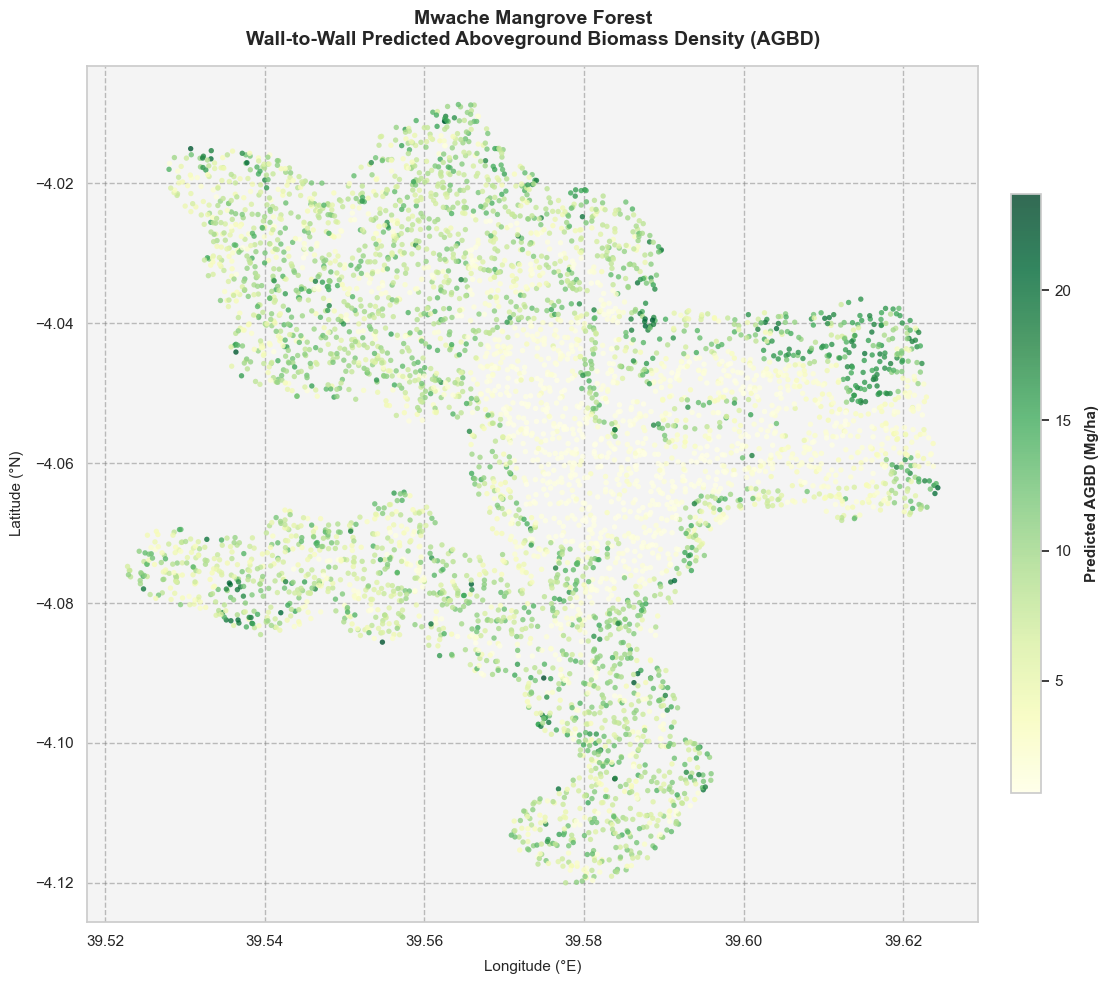

In [36]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# =========================================================================
# 1. Load Mapped Predictions & Convert to GeoDataFrame
# =========================================================================
prediction_csv = r"D:\other\4me\mwache\mwache_wall_to_wall_predicted_agbd.csv"
df_plot = pd.read_csv(prediction_csv)

# Convert coordinates into Point geometries
geometry = [Point(xy) for xy in zip(df_plot['x_long'], df_plot['y_lat'])]
gdf_pred = gpd.GeoDataFrame(df_plot, geometry=geometry, crs="EPSG:4326")

# =========================================================================
# 2. Design and Render the Spatial Map
# =========================================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the predicted AGBD values using a continuous color scale
# 'YlGn' is highly recommended for vegetation/biomass metrics
scatter = ax.scatter(
    df_plot['x_long'], 
    df_plot['y_lat'], 
    c=df_plot['predicted_agbd'], 
    cmap='YlGn', 
    s=15,          # Adjust point size depending on density
    alpha=0.8,     # Slight transparency to see overlapping points
    edgecolors='none'
)

# Format axes and background
ax.set_facecolor('#f4f4f4')
ax.grid(True, linestyle='--', alpha=0.5, color='gray')

# Add Labels and Context
ax.set_title("Mwache Mangrove Forest\nWall-to-Wall Predicted Aboveground Biomass Density (AGBD)", fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel("Longitude (°E)", fontsize=11, labelpad=8)
ax.set_ylabel("Latitude (°N)", fontsize=11, labelpad=8)

# Add a professional colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', shrink=0.7, pad=0.03)
cbar.set_label("Predicted AGBD (Mg/ha)", fontsize=11, labelpad=10, fontweight='bold')

# Prevent scientific notation on coordinate ticks
ax.ticklabel_format(useOffset=False, style='plain')

plt.tight_layout()

# Save the map as a high-res image
output_map_img = r"D:\other\4me\mwache\mwache_predicted_agbd_map.png"
plt.savefig(output_map_img, dpi=300, bbox_inches='tight')
print(f"[✔] Visual map plot successfully saved to: {output_map_img}")

# Display the map window
plt.show()

To get a smooth, continuous surface map of AGBD instead of separate dot-shaped point markers, I turn  tabular spreadsheet outputs into a structured geographic raster grid (GeoTIFF).

By converting prediction DataFrame into a GeoDataFrame, generating a gridded spatial raster, and then mapping it smoothly.
Generate a Smooth Raster Map (Save as GeoTIFF & Plot)
outputs into a continuous matrix using a clean yellow-to-green interpolation layout:


In [37]:
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# =========================================================================
# 1. Load Prediction Matrix
# =========================================================================
prediction_csv = r"D:\other\4me\mwache\mwache_wall_to_wall_predicted_agbd.csv"
df = pd.read_csv(prediction_csv)

x = df['x_long'].values
y = df['y_lat'].values
z = df['predicted_agbd'].values

# =========================================================================
# 2. Interpolate Vector Points onto a Dense Continuous Grid Mesh
# =========================================================================
# Define your bounding domain edges
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

# Establish the grid dimensions (adjust to tweak rendering sharpness)
grid_width = 500  
grid_height = 500

grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, grid_width),
    np.linspace(y_min, y_max, grid_height)
)

# Linearly fill gaps between your sampled prediction coordinates
grid_z = grid_data = griddata((x, y), z, (grid_x, grid_y), method='linear')

# Flip the raster array structurally to conform with top-down geographic axes
grid_z_flipped = np.flipud(grid_z)

# =========================================================================
# 3. Export the Results Cleanly as a GIS GeoTIFF
# =========================================================================
res_x = (x_max - x_min) / grid_width
res_y = (y_max - y_min) / grid_height
transform = from_origin(x_min, y_max, res_x, res_y)

output_tiff = r"D:\other\4me\mwache\mwache_continuous_agbd.tif"
with rasterio.open(
    output_tiff, 'w', driver='GTiff',
    height=grid_height, width=grid_width,
    count=1, dtype=str(grid_z.dtype),
    crs='EPSG:4326', transform=transform,
    nodata=np.nan
) as dst:
    dst.write(grid_z_flipped, 1)

print(f"[✔] Continuous Wall-to-Wall Raster Map exported to: {output_tiff}")

# =========================================================================
# 4. Generate the Smooth Map Canvas Output
# =========================================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_facecolor('#dcdcdc') # Neutral grey backdrop to emphasize forest edge contours

# Display the continuous raster interpolation
im = ax.imshow(
    grid_z, 
    extent=(x_min, x_max, y_min, y_max), 
    origin='lower', 
    cmap='YlGn', # Soft light-yellow to deep forest-green ramp
    alpha=0.9
)

ax.set_title("Mwache Mangrove Forest\nSmooth Continuous Aboveground Biomass Density (AGBD)", fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel("Longitude (°E)", labelpad=8)
ax.set_ylabel("Latitude (°N)", labelpad=8)

# Format colorbar cleanly
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.03)
cbar.set_label("Predicted AGBD (Mg/ha)", fontweight='bold', labelpad=10)

ax.ticklabel_format(useOffset=False, style='plain')
plt.tight_layout()

# Save image file
output_png = r"D:\other\4me\mwache\mwache_continuous_agbd_map.png"
plt.savefig(output_png, dpi=300, bbox_inches='tight')
plt.show()

CRSError: The EPSG code is unknown. PROJ: proj_create_from_database: C:\Program Files\PostgreSQL\16\share\contrib\postgis-3.4\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 5 is expected. It comes from another PROJ installation.

In [ ]:
# include only relevant indices for mangrove . establish agb then perform random forest regression

In [43]:
#!pip install planetary-computer

##### workflow is:

- pick best valid ocean cell from shapefile
- compute tide from that single stable reference point
- build full 2026 time series
- find lowest tide day
- plot

Polygon



Instead of relying on tile cloud percentage, i evaluate cloud cover within the AOI since the CLOUDY_PIXEL_PERCENTAGE is for entire sentinel_2 tile (e.g An image reported as 5% cloudy can still have clouds directly over the mangroves, while a 40% cloudy tile may be perfectly clear over your AOI)  

Option 1: Use the Sentinel-2 Cloud Probability dataset

Join Sentinel-2 with the cloud probability collection and compute cloudiness over the  AOI.

In [48]:
#### visualizing